# CNET 5442 — Sports Analytics Through Data and Networks (Spring 2026)  
## Class 12: Toward March Madness Prediction

### Motivation (why are we doing this?)
March Madness is a rare combination of (i) a huge, well-defined prediction problem, (ii) a scoring system that rewards correct *sequences* of decisions, and (iii) enough randomness that even good models will sometimes look "wrong."

That makes it a perfect setting for learning machine learning in a way that stays grounded: we will build models that output **probabilities**, evaluate them with metrics that *match the decision problem*, and then convert those probabilities into bracket picks and bracket simulations.

### What you'll learn
By the end of this notebook, you should be able to:

- Use the standard scientific Python stack for end-to-end supervised learning (NumPy, pandas, scikit-learn).
- Explain the difference between **prediction**, **inference**, and **evaluation** in a sports analytics setting.
- Build a clean modeling dataset for game outcomes from team-season features.
- Fit and interpret a **logistic regression** model for win probabilities.
- Understand **decision trees** and **random forests** at an intuitive level (what they are doing, and why they often work well).
- Fit a **random forest** model for win probabilities and compare it fairly to logistic regression on a held-out season.
- Evaluate probabilistic classifiers with **log loss**, **Brier score**, **ROC-AUC**, and calibration diagnostics.
- Turn game-level win probabilities into a **tournament bracket** (and simulate many brackets).

This notebook contains more material than fits in a single class session. Sections marked **Optional** are great for after-class reading or if you want a deeper dive.

---

## 0. Setup

We'll do two things in parallel throughout:

1. Learn the *general* machine learning ideas with tiny toy examples.
2. Apply the same ideas to a real March Madness dataset.

Some appendices are computationally heavier. You can control whether they run using `RUN_OPTIONAL` below.

In sports analytics, machine learning is rarely just fitting a model. It's usually a pipeline discipline:

1. Decide what the *prediction problem* is and what the model will be allowed to know at prediction time.
2. Build a dataset where each row corresponds to one prediction event (here: a tournament game).
3. Split the data so evaluation mimics the real forecasting situation (here: hold out an entire season).
4. Fit models on the training set, tune choices using only training data (via cross-validation), and evaluate once on the held-out test season.

We will keep returning to that pipeline as we add models and build toward bracket simulation.

In [1]:
import os
from pathlib import Path
import re
import zipfile

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display

from matplotlib import rc
plt.rc('axes', axisbelow=True)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'

pd.set_option('display.max_columns', 150)

# scikit-learn: the core ML workflow
from sklearn.model_selection import GroupKFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_moons
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    brier_score_loss,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Reproducibility
RNG = np.random.default_rng(5442)

# Optional/Appendix controls
RUN_OPTIONAL = True      # set to True to run heavier appendices
N_TOURNEY_SIMS = 300      # increase if you want a smoother simulation histogram

print("numpy:", np.__version__)
print("pandas:", pd.__version__)


numpy: 1.22.0
pandas: 2.0.3


### 0.2 A 60-second orientation: tables, matrices, and `fit` / `predict_proba`

Two data shapes appear everywhere in machine learning:

- A feature matrix $X$ with shape $(n, p)$: $n$ examples (games), $p$ features (numbers describing each game).
- A label vector $y$ with shape $(n,)$: one outcome per example.

In **scikit-learn**, the modeling pattern is extremely consistent:

1. `model = ...` (choose an algorithm and settings)
2. `model.fit(X_train, y_train)` (learn from historical data)
3. `model.predict_proba(X_test)` (output probabilities on new games)
4. evaluate with metrics like log loss

Below is a tiny "hello world" example with four fake games. The point is not the model quality — it's the workflow and the data shapes.

In [2]:
# A tiny "hello world" dataset (4 made-up games)
mini = pd.DataFrame({
    "rating_diff": [5, -3, 2, -1],      # Team1 rating minus Team2 rating
    "seed_diff":   [-2, 4, -1, 1],      # Team1 seed minus Team2 seed (lower is better)
    "team1_win":   [1, 0, 1, 0],        # label: 1 if Team1 won, 0 otherwise
})

In [3]:
mini

,rating_diff,seed_diff,team1_win
0,5,-2,1
1,-3,4,0
2,2,-1,1
3,-1,1,0


In [4]:
# In scikit-learn:
# - X is a 2D matrix of features (rows=examples, columns=features)
# - y is a 1D vector of labels
X_mini = mini[["rating_diff", "seed_diff"]]
y_mini = mini["team1_win"]

print("X_mini shape:", X_mini.shape)  # (n_examples, n_features)
print("y_mini shape:", y_mini.shape)  # (n_examples,)

X_mini shape: (4, 2)
y_mini shape: (4,)


In [5]:
hello = LogisticRegression(solver="lbfgs", max_iter=2000)
hello.fit(X_mini, y_mini)

LogisticRegression(max_iter=2000)

In [6]:
# predict_proba returns 2 columns for binary classification:
# - column 0: P(y=0)
# - column 1: P(y=1)
p_hat = hello.predict_proba(X_mini)[:, 1]

In [7]:
mini_out = mini.copy()
mini_out["p_hat_team1_win"] = p_hat

In [8]:
# Sanity checks
assert np.all((mini_out["p_hat_team1_win"] >= 0) & (mini_out["p_hat_team1_win"] <= 1))
mini_out

,rating_diff,seed_diff,team1_win,p_hat_team1_win
0,5,-2,1,0.982203
1,-3,4,0,0.014370
2,2,-1,1,0.817343
3,-1,1,0,0.186077


---

## 1. What is machine learning?

A practical (sports-analytics-friendly) definition:

> We have historical data with outcomes we care about. We choose a set of inputs (features), pick a flexible function class (a model), and fit the model by optimizing a criterion that rewards good predictions. Then we check performance on data the model did not see.

In supervised learning, we observe pairs $(x_i, y_i)$:

- $x_i$ is the **feature vector** for example $i$ (numbers describing the situation).
- $y_i$ is the **label** or **target** (what happened).

In March Madness, a natural label is:

- $y_i = 1$ if Team A won game $i$  
- $y_i = 0$ if Team A lost game $i$

We will build models that output a **probability** $p_i$ that Team A wins:

$$
p_i = P(y_i = 1 \,|\, x_i)
$$

**Why probabilities?**  
Because probabilities let us (i) compare across games, (ii) simulate brackets, and (iii) use scoring rules like log loss that punish "false confidence."


---

## 2. A tiny running example: turning features into win probabilities

Before touching basketball data, we'll build a toy model where we know the ground truth.

### Data generating process (a simple story)

Suppose each game has a single feature $x$:

- $x$ could be "Team A rating minus Team B rating."
- Larger $x$ should mean Team A is more likely to win.

We generate win probabilities using a **sigmoid** function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Definitions (right away):

- $z$ is any real number (positive or negative).
- $e$ is Euler's number ($e \approx 2.718$).
- $\sigma(z)$ is always between $0$ and $1$, so it's valid as a probability.


Why this form makes sense:

- If $z$ is large and positive, $e^{-z}$ is tiny, so $\sigma(z) \approx 1$.
- If $z$ is large and negative, $e^{-z}$ is huge, so $\sigma(z) \approx 0$.
- If $z = 0$, then $\sigma(0) = 1/2$ (a "coin flip" game).

We'll use a linear score $z = \beta_0 + \beta_1 x$:

$$
p = P(y=1 \mid x) = \sigma(\beta_0 + \beta_1 x)
$$


Symbol map:

- $x$ is our feature (a number).
- $\beta_0$ is the intercept (baseline advantage).
- $\beta_1$ is the slope (how strongly $x$ changes the win chance).
- $p$ is the predicted probability that Team A wins.

Next we'll compute $p$ for a few numeric values (by hand and in code), then simulate data.

In [9]:
def sigmoid(z):
    """Compute the logistic sigmoid function.

    Mathematical definition:
        $$\sigma(z) = \frac{1}{1 + e^{-z}}$$

    Parameters
    ----------
    z : float or array-like
        The input score(s). In logistic regression, $z$ is often a linear score like
        $z = \beta_0 + \beta^T x$.

    Returns
    -------
    sigma : float or np.ndarray
        Value(s) in $(0, 1)$, interpretable as probabilities.

    Notes
    -----
    This implementation relies on NumPy broadcasting, so it works for:
    - a single number (scalar)
    - a vector of scores
    - a matrix of scores
    """
    return 1 / (1 + np.exp(-z))


# Tiny numeric examples (notice the outputs are always between 0 and 1)
zs = np.array([-3, -1, 0, 1, 3], dtype=float)
pd.DataFrame({"z": zs, "sigma(z)": sigmoid(zs)})


,z,sigma(z)
0,-3.0,0.047426
1,-1.0,0.268941
2,0.0,0.500000
3,1.0,0.731059
4,3.0,0.952574


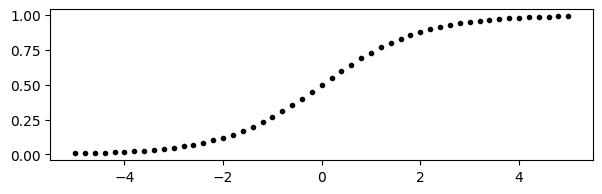

In [10]:
fig, ax = plt.subplots(1,1,figsize=(7,2),dpi=100)

zs = np.linspace(-5,5,51)
yy = pd.DataFrame({"z": zs, "sigma(z)": sigmoid(zs)})

ax.plot(yy['z'].values,yy['sigma(z)'].values,color='k',marker='.',lw=0)


plt.show()

### Another tiny numeric example: from $x$ to $p$

Let $\beta_0 = 0$ and $\beta_1 = 1$. Then $p = \sigma(x)$.

- If $x=-1$, then $p = \sigma(-1) \approx 0.269$.
- If $x=0$, then $p = 0.5$.
- If $x=1$, then $p \approx 0.731$.

Now we'll confirm with code.


In [11]:
beta0 = 0.0
beta1 = 1.0

xs = np.array([-1, 0, 1], dtype=float)
pd.DataFrame({"x": xs, "p": sigmoid(beta0 + beta1 * xs)})

,x,p
0,-1.0,0.268941
1,0.0,0.500000
2,1.0,0.731059


### Simulating game outcomes

We will now generate $n$ games:

1. Draw $x_i$ values.
2. Compute probabilities $p_i = \sigma(\beta_0 + \beta_1 x_i)$.
3. Draw outcomes $y_i \sim \text{Bernoulli}(p_i)$.

The Bernoulli distribution means:

- $P(y_i = 1) = p_i$
- $P(y_i = 0) = 1 - p_i$

This is the simplest "win/loss" model imaginable --- we've seen it before in class!


In [12]:
# Simulate data
n = 500
beta0_true = -0.2
beta1_true = 1.3

x = RNG.normal(loc=0.0, scale=1.0, size=n)
p_true = sigmoid(beta0_true + beta1_true * x)
y = RNG.binomial(n=1, p=p_true, size=n)

toy = pd.DataFrame({"x": x, "p_true": p_true, "y": y})
toy.head()


,x,p_true,y
0,-0.330103,0.347707,0
1,0.232509,0.525543,1
2,-0.871168,0.208743,0
3,1.208794,0.797611,1
4,-0.118573,0.412378,1


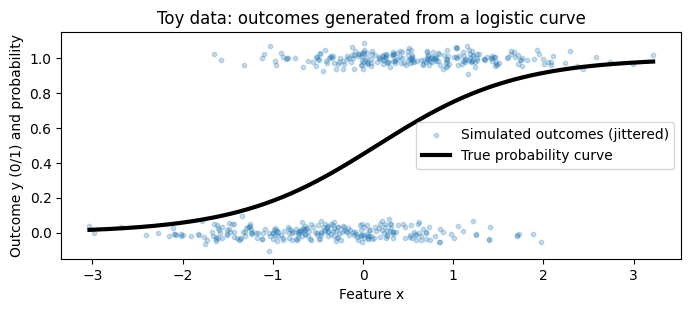

In [13]:
# Visualize the simulated relationship
xs_grid = np.linspace(toy["x"].min(), toy["x"].max(), 200)
ps_grid = sigmoid(beta0_true + beta1_true * xs_grid)

fig, ax = plt.subplots(figsize=(8,3), dpi=100)
y_jitter = toy["y"] + RNG.normal(0, 0.03, size=len(toy))

ax.scatter(toy["x"], y_jitter, s=10, alpha=0.25, label="Simulated outcomes (jittered)")
ax.plot(xs_grid, ps_grid, linewidth=3, label="True probability curve", color='k')

ax.set_xlabel("Feature x")
ax.set_ylabel("Outcome y (0/1) and probability")
ax.set_title("Toy data: outcomes generated from a logistic curve")
ax.set_ylim(-0.15, 1.15)
ax.legend()

plt.show()


### Fitting logistic regression on the toy data

Logistic regression assumes:

$$
P(y=1 \mid x) = \sigma(\beta_0 + \beta_1 x)
$$

Same symbols as before, but now $\beta_0$ and $\beta_1$ are **unknown** and must be estimated from data.

A key interpretation comes from the **log-odds** (also called the logit):

$$
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x
$$

Definitions:

- $p$ is the win probability.
- $p/(1-p)$ is the **odds** of winning.
- The log-odds is a real number, so it can be modeled linearly.

Intuition:

- A one-unit increase in $x$ increases the log-odds by $\beta_1$.
- Exponentiating, it multiplies the odds by $e^{\beta_1}$.

We'll fit a model and compare the estimated coefficients to the true ones used to generate the data.


In [14]:
# Micro-check: log-odds for a few probabilities
ps = np.array([0.2, 0.5, 0.8])
pd.DataFrame({"p": ps, "log(p/(1-p))": np.log(ps / (1 - ps))})


,p,log(p/(1-p))
0,0.2,-1.386294
1,0.5,0.000000
2,0.8,1.386294


In [15]:
X_toy = toy[["x"]].values
y_toy = toy["y"].values

![](images/train_test_split.png)

In [16]:
X_train_toy, X_test_toy, y_train_toy, y_test_toy = train_test_split(
    X_toy, y_toy, test_size=0.25, random_state=5442, stratify=y_toy
)

In [17]:
toy_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=2000))
])

toy_model.fit(X_train_toy, y_train_toy)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=2000))])

In [18]:
scaler = toy_model.named_steps["scaler"]
logreg = toy_model.named_steps["logreg"]

In [19]:
beta1_std = logreg.coef_.ravel()[0]
beta0_std = logreg.intercept_[0]

# Convert coefficients back to the original x-scale so we can compare to the true (beta0_true, beta1_true).
beta1_hat = beta1_std / scaler.scale_[0]
beta0_hat = beta0_std - beta1_std * scaler.mean_[0] / scaler.scale_[0]

print("True beta0, beta1:", beta0_true, beta1_true)
print("Estimated beta0, beta1 (approx):", beta0_hat, beta1_hat)

p_test_toy = toy_model.predict_proba(X_test_toy)[:, 1]
print("Test log loss:", log_loss(y_test_toy, p_test_toy))
print("Test accuracy (threshold 0.5):", accuracy_score(y_test_toy, (p_test_toy >= 0.5).astype(int)))

True beta0, beta1: -0.2 1.3
Estimated beta0, beta1 (approx): -0.19627809922334238 1.4289401020054397
Test log loss: 0.5877728334334711
Test accuracy (threshold 0.5): 0.688


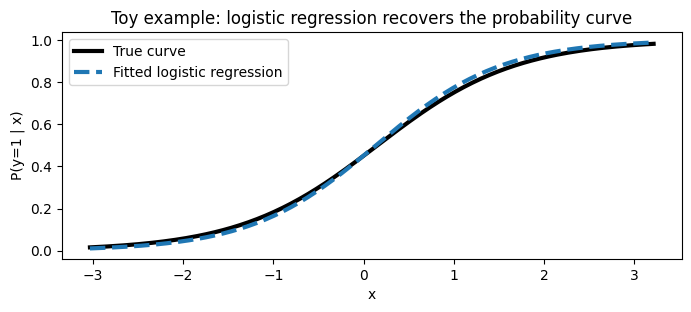

In [20]:
# Plot fitted probabilities vs true curve
xs_grid = np.linspace(toy["x"].min(), toy["x"].max(), 200)
ps_true = sigmoid(beta0_true + beta1_true * xs_grid)
ps_fit = toy_model.predict_proba(xs_grid.reshape(-1, 1))[:, 1]

fig, ax = plt.subplots(figsize=(8, 3), dpi=100)
ax.plot(xs_grid, ps_true, linewidth=3, label="True curve", color='k')
ax.plot(xs_grid, ps_fit, linewidth=3, linestyle="--", label="Fitted logistic regression")

ax.set_xlabel("x")
ax.set_ylabel("P(y=1 | x)")
ax.set_title("Toy example: logistic regression recovers the probability curve")
ax.legend()
plt.show()

---

## 3. Evaluation: why accuracy is not enough (especially for brackets)

In classification, it's tempting to ask: "Did we pick the winner?" That's **accuracy**.

But for March Madness we usually care about **probabilistic** predictions, because:

- A 55–45 game is qualitatively different from a 95–5 game.
- Bracket simulation needs probabilities.
- Many competitions use **log loss**, which punishes confident wrong predictions more than cautious ones.

We'll define and compute four common metrics.

### 3.1 Accuracy

Given predicted labels $\hat{y}_i \in \{0,1\}$ and true labels $y_i$:

$$
\text{Accuracy} = \frac{1}{n}\sum_{i=1}^n \mathbf{1}[\hat{y}_i = y_i]
$$

Definitions:

- $n$ is the number of examples.
- $\mathbf{1}[\cdot]$ is an indicator: 1 if the condition is true, else 0.

Accuracy depends on a threshold (often $0.5$) to convert probabilities into labels.


### 3.2 Log loss (binary cross-entropy)

Given predicted probabilities $p_i$ (for $y_i=1$):

$$
\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^n \left( y_i\log(p_i) + (1-y_i)\log(1-p_i) \right)
$$

Definitions:

- If $y_i=1$, we pay $-\log(p_i)$ (high penalty if $p_i$ is small).
- If $y_i=0$, we pay $-\log(1-p_i)$ (high penalty if $p_i$ is close to 1).

### 3.3 Brier score

The Brier score is a squared-error metric for probabilities:

$$
\text{Brier} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i)^2
$$


### 3.4 ROC-AUC (ranking quality)

ROC-AUC measures how well the model *ranks* winners above losers.

One (equivalent) view:

- Pick a random win example and a random loss example.
- ROC-AUC is the probability the win example gets a higher predicted probability than the loss example.

A random model has ROC-AUC $0.5$; a perfect ranking has $1.0$.

Next: a tiny numeric example that shows how log loss reacts to overconfidence.


In [21]:
# Tiny numeric example for log loss and Brier score
#
# The goal of this cell is *intuition*:
# - log loss heavily punishes "confident wrong" probabilities
# - Brier score is a more gently-behaved squared error for probabilities

y_small = np.array([1, 0, 1], dtype=int)

In [22]:
# Two sets of probabilities:
# - "Cautious": never too close to 0 or 1
# - "Overconfident": extremely sure on the first two games
p_cautious = np.array([0.70, 0.40, 0.60], dtype=float)
p_overconf = np.array([0.99, 0.01, 0.60], dtype=float)

In [23]:
def log_loss_manual(y, p, eps=1e-15):
    """Manual binary log loss (binary cross-entropy) with clipping.

    Formula (matches the definition in the notes above):
        $$\text{LogLoss} = -\frac{1}{n}\sum_{i=1}^n \left[y_i\log(p_i) + (1-y_i)\log(1-p_i)\right]$$

    Parameters
    ----------
    y : array-like, shape (n,)
        Binary labels in {0, 1}.
    p : array-like, shape (n,)
        Predicted probabilities for y=1.
    eps : float
        Numerical stability constant. We clip p into [eps, 1-eps] so we never take log(0).

    Returns
    -------
    float
        Mean log loss across the n examples.
    """
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)

    # Basic invariants we want to enforce (tiny tests)
    assert y.shape == p.shape
    assert set(np.unique(y)).issubset({0.0, 1.0})

    # Clip probabilities away from exactly 0 or 1
    p = np.clip(p, eps, 1 - eps)

    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

In [24]:
def brier_manual(y, p):
    """Manual Brier score (mean squared error for probabilities).

    Formula:
        $$\text{Brier} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i)^2$$

    Parameters
    ----------
    y : array-like, shape (n,)
        Binary labels in {0, 1}.
    p : array-like, shape (n,)
        Predicted probabilities for y=1.

    Returns
    -------
    float
        Mean squared error between p and y.
    """
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    assert y.shape == p.shape
    return np.mean((p - y) ** 2)

In [25]:
out = pd.DataFrame({
    "case": ["cautious", "overconfident"],
    "log_loss_manual": [log_loss_manual(y_small, p_cautious), log_loss_manual(y_small, p_overconf)],
    "brier_manual": [brier_manual(y_small, p_cautious), brier_manual(y_small, p_overconf)],
    "log_loss_sklearn": [log_loss(y_small, p_cautious), log_loss(y_small, p_overconf)],
    "brier_sklearn": [brier_score_loss(y_small, p_cautious), brier_score_loss(y_small, p_overconf)],
})
out

,case,log_loss_manual,brier_manual,log_loss_sklearn,brier_sklearn
0,cautious,0.459442,0.136667,0.459442,0.136667
1,overconfident,0.176975,0.053400,0.176975,0.053400


In [26]:
# How bad is a confident wrong prediction in log loss?
y_bad = np.array([1])
p_bad = np.array([0.01])  # model said 1% chance, but event happened

print("Log loss for a confident wrong prediction:", log_loss_manual(y_bad, p_bad))
print("Compare to a cautious prediction p=0.4:", log_loss_manual(y_bad, np.array([0.4])))


Log loss for a confident wrong prediction: 4.605170185988091
Compare to a cautious prediction p=0.4: 0.916290731874155


---

## 4. March Madness data: where the modeling dataset comes from

We will use the **March Machine Learning Mania** dataset (Kaggle). It includes:

- Regular-season game results (including box score detail).
- Tournament seeds and tournament game results (historical).
- Bracket structure (which seed plays which seed in each round).

The key challenge is **data engineering**:

> Tournament games happen between teams that do not play each other often.  
> We need to summarize each team's season into a feature vector, then compare teams.

### A note on seasons and coverage

In this dataset:

- Men's regular-season *detailed* results start in 2003.
- Tournament results exist for earlier seasons, but without the same feature richness.

To keep features consistent, we will build models using seasons where we have detailed regular-season data (2003 and later).


In [27]:
extract_dir = 'data/march-machine-learning-mania-2026/'

teams = pd.read_csv(extract_dir + "MTeams.csv")
seeds = pd.read_csv(extract_dir + "MNCAATourneySeeds.csv")
tourney = pd.read_csv(extract_dir + "MNCAATourneyCompactResults.csv")
rs_detail = pd.read_csv(extract_dir + "MRegularSeasonDetailedResults.csv")
slots = pd.read_csv(extract_dir + "MNCAATourneySlots.csv")

print("teams:", teams.shape)
print("seeds:", seeds.shape)
print("tourney:", tourney.shape)
print("rs_detail:", rs_detail.shape)
print("slots:", slots.shape)

teams: (381, 4)
seeds: (2626, 3)
tourney: (2585, 8)
rs_detail: (122775, 34)
slots: (2586, 4)


### What's in these tables?

We will repeatedly use a few key identifiers:

- **Season**: an integer year label (e.g., 2025).
- **TeamID**: a stable numeric ID for a team.

The tables:

- `MTeams.csv` maps `TeamID` to a readable `TeamName`.
- `MRegularSeasonDetailedResults.csv` contains game-by-game box score stats for the regular season.
- `MNCAATourneySeeds.csv` contains each tournament team's **seed** (like `W01`, `X16a`).
- `MNCAATourneyCompactResults.csv` contains tournament game outcomes (winner/loser and score).
- `MNCAATourneySlots.csv` encodes the bracket structure: which seed plays which seed in each round.

Next we'll build team-season features from regular-season games.


In [28]:
display(teams.head())
display(seeds.head())
display(tourney.head())
display(rs_detail.head())

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14


---

## 5. Feature engineering: summarizing a team's season

A tournament game is between two teams, but the regular season contains *many* games. We need a fixed-length feature vector for each team-season.

A simple approach is to build season summaries:

- win percentage
- average point differential
- estimated possessions per game (tempo)
- offensive efficiency (points per 100 possessions)
- defensive efficiency (opponent points per 100 possessions)
- a few shooting and turnover rates

These are not "perfect" measures — they ignore opponent strength and home/away context — but they are an excellent teaching scaffold and already surprisingly informative.


### 5.1 Estimating possessions (tempo)

We need possessions to convert points into efficiency.

A common possession estimate is:

$$
\text{Possessions} = \text{FGA} - \text{OR} + \text{TO} + 0.475\,\text{FTA}
$$

Definitions:

- $\text{FGA}$: field goal attempts
- $\text{OR}$: offensive rebounds
- $\text{TO}$: turnovers
- $\text{FTA}$: free throw attempts
- The constant $0.475$ approximates how many free throw attempts "consume" a possession on average.

So: if a team has $\text{FGA}=60$, $\text{OR}=10$, $\text{TO}=12$, $\text{FTA}=20$:

$$
\text{Poss} = 60 - 10 + 12 + 0.475\cdot 20 = 71.5
$$

In practice we often compute possessions for *both* teams and average them to reduce noise.


In [29]:
FGA, OR, TO, FTA = 60, 10, 12, 20
FGA - OR + TO + 0.475 * FTA


71.5

### 5.2 From game-level box scores to team-game rows

`MRegularSeasonDetailedResults.csv` stores each game in one row, but with separate columns for the winner (prefix `W`) and loser (prefix `L`).

For modeling, it's often easier to work in a "long" format:

- one row per **team-game** (so each game becomes two rows: one for each team)

Then we can compute team stats, opponent stats, and whether the team won.


In [30]:
def build_team_game_long(rs_detail_df):
    """Convert regular-season detailed results to a "long" team-game format.

    Kaggle's `MRegularSeasonDetailedResults.csv` stores one row per game, with two
    "blocks" of columns: one block for the winner (prefix `W`) and one block for
    the loser (prefix `L`). For many feature engineering tasks, it is more natural
    to work with *one row per team per game* (a "team-game" row).

    This function turns each game into two rows:

    - winner row: TeamID = WTeamID, OppTeamID = LTeamID, Win=1
    - loser row:  TeamID = LTeamID, OppTeamID = WTeamID, Win=0

    We also rename the winner/loser stat columns into a consistent schema:

    - Team_Score, Team_FGA, Team_TO, ...
    - Opp_Score,  Opp_FGA,  Opp_TO,  ...

    Parameters
    ----------
    rs_detail_df : pandas.DataFrame
        The raw Kaggle regular-season detailed results.

    Returns
    -------
    pandas.DataFrame
        Long-format team-game table with one row per team per game.
    """
    # These columns exist once per game (not duplicated for each team)
    base_cols = ["Season", "DayNum", "WLoc", "NumOT"]

    # These appear with both W and L prefixes
    stat_suffixes = [
        "Score", "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA",
        "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF"
    ]

    # Keep the same structure for winner and loser blocks
    keep_w = (
        base_cols
        + ["WTeamID", "LTeamID"]
        + [f"W{s}" for s in stat_suffixes]
        + [f"L{s}" for s in stat_suffixes]
    )
    keep_l = (
        base_cols
        + ["LTeamID", "WTeamID"]
        + [f"L{s}" for s in stat_suffixes]
        + [f"W{s}" for s in stat_suffixes]
    )

    # Winner row
    w = rs_detail_df[keep_w].copy()
    w.rename(columns={"WTeamID": "TeamID", "LTeamID": "OppTeamID"}, inplace=True)
    w["Win"] = 1

    # Loser row
    l = rs_detail_df[keep_l].copy()
    l.rename(columns={"LTeamID": "TeamID", "WTeamID": "OppTeamID"}, inplace=True)
    l["Win"] = 0

    # Rename the stat columns to a consistent Team_ / Opp_ schema
    rename_map_w = {f"W{s}": f"Team_{s}" for s in stat_suffixes}
    rename_map_w.update({f"L{s}": f"Opp_{s}" for s in stat_suffixes})

    rename_map_l = {f"L{s}": f"Team_{s}" for s in stat_suffixes}
    rename_map_l.update({f"W{s}": f"Opp_{s}" for s in stat_suffixes})

    w.rename(columns=rename_map_w, inplace=True)
    l.rename(columns=rename_map_l, inplace=True)

    long_df = pd.concat([w, l], ignore_index=True)

    # Lightweight sanity checks
    assert long_df.shape[0] == 2 * rs_detail_df.shape[0], "Expected two rows per game (winner + loser)."
    assert set(["Season", "DayNum", "TeamID", "OppTeamID", "Win"]).issubset(long_df.columns)

    return long_df


def estimate_possessions(fga, or_, to, fta):
    """Estimate possessions for a team in a single game.

    Basketball "possessions" are not explicitly recorded in a box score, but many
    tempo-free stats depend on them. A common approximation (popularized by Dean Oliver)
    is:

    $$\text{Poss} = \text{FGA} - \text{OR} + \text{TO} + 0.475 \cdot \text{FTA}.$$

    Definitions (per team, per game):
    - FGA = field goal attempts
    - OR  = offensive rebounds
    - TO  = turnovers
    - FTA = free throw attempts

    The idea is: a possession typically ends with a shot attempt, a turnover, or a
    trip to the free throw line, but offensive rebounds extend possessions.

    Parameters
    ----------
    fga, or_, to, fta : array-like
        Arrays or pandas Series of box-score counts.

    Returns
    -------
    array-like
        Estimated possessions for each row.
    """
    return fga - or_ + to + 0.475 * fta

In [31]:
team_games = build_team_game_long(rs_detail)

# Add estimated possessions as a new column
team_games["Poss"] = estimate_possessions(
    team_games["Team_FGA"],
    team_games["Team_OR"],
    team_games["Team_TO"],
    team_games["Team_FTA"],
)

display(team_games.head())

,Season,DayNum,WLoc,NumOT,TeamID,OppTeamID,Team_Score,Team_FGM,Team_FGA,Team_FGM3,Team_FGA3,Team_FTM,Team_FTA,Team_OR,Team_DR,Team_Ast,Team_TO,Team_Stl,Team_Blk,Team_PF,Opp_Score,Opp_FGM,Opp_FGA,Opp_FGM3,Opp_FGA3,Opp_FTM,Opp_FTA,Opp_OR,Opp_DR,Opp_Ast,Opp_TO,Opp_Stl,Opp_Blk,Opp_PF,Win,Poss
0,2003,10,N,0,1104,1328,68,27,58,3,14,11,18,14,24,13,23,7,1,22,62,22,53,2,10,16,22,10,22,8,18,9,2,20,1,75.550
1,2003,10,N,0,1272,1393,70,26,62,8,20,10,19,15,28,16,13,4,4,18,63,24,67,6,24,9,20,20,25,7,12,8,6,16,1,69.025
2,2003,11,N,0,1266,1437,73,24,58,8,18,17,29,17,26,15,10,5,2,25,61,22,73,3,26,14,23,31,22,9,12,2,5,23,1,64.775
3,2003,11,N,0,1296,1457,56,18,38,3,9,17,31,6,19,11,12,14,2,18,50,18,49,6,22,8,15,17,20,9,19,4,3,23,1,58.725
4,2003,11,N,0,1400,1208,77,30,61,6,14,11,13,17,22,12,14,4,4,20,71,24,62,6,16,17,27,21,15,12,10,7,1,14,1,64.175


### 5.3 Aggregating to team-season features

For a given team $t$ in season $s$, let:

- $G_{ts}$ be the number of games
- $W_{ts}$ be the number of wins
- $\text{PtsFor}_{ts}$ be total points scored
- $\text{PtsAgainst}_{ts}$ be total points allowed
- $\text{Poss}_{ts}$ be total estimated possessions


Then:

$$
\text{WinPct}_{ts} = \frac{W_{ts}}{G_{ts}}
$$

$$
\text{OffEff}_{ts} = 100\cdot \frac{\text{PtsFor}_{ts}}{\text{Poss}_{ts}}, 
\quad
\text{DefEff}_{ts} = 100\cdot \frac{\text{PtsAgainst}_{ts}}{\text{Poss}_{ts}}
$$

$$
\text{Tempo}_{ts} = \frac{\text{Poss}_{ts}}{G_{ts}}
$$

For shooting efficiency:

$$
\text{eFG}_{ts} = \frac{\text{FGM}_{ts} + 0.5\,\text{FGM3}_{ts}}{\text{FGA}_{ts}}
$$

Micro-check with a tiny made-up season:


In [32]:
G = 30
W = 18
PtsFor = 2300
PtsAgainst = 2150
PossTot = 2100

FGM = 800
FGM3 = 250
FGA = 1800

pd.Series({
    "WinPct": W / G,
    "OffEff": 100 * PtsFor / PossTot,
    "DefEff": 100 * PtsAgainst / PossTot,
    "Tempo": PossTot / G,
    "eFG": (FGM + 0.5 * FGM3) / FGA
})


WinPct      0.600000
OffEff    109.523810
DefEff    102.380952
Tempo      70.000000
eFG         0.513889
dtype: float64

In [33]:
def build_team_season_features(team_games_df):
    """Aggregate team-game rows into one row per (Season, TeamID).

    This is our first example of a very common pattern in sports analytics:

    1. Start with "event-level" data (games, possessions, plays, shots, ...)
    2. Aggregate into a fixed-length feature vector per unit of interest
       (team-season, player-season, lineup, ...)
    3. Use that feature vector to predict outcomes of future events

    Here, we compress each team-season into tempo-free summaries:

    - WinPct, MarginPG
    - Tempo (estimated possessions per game)
    - OffEff, DefEff, NetEff (points per 100 possessions)
    - eFG, TOV_rate, FTR, ORB_rate

    Parameters
    ----------
    team_games_df : pandas.DataFrame
        Long team-game table with columns like Team_Score, Opp_Score, Poss, etc.

    Returns
    -------
    pandas.DataFrame
        One row per (Season, TeamID), with engineered feature columns.
    """
    # Aggregate raw counts over the season
    agg = (
        team_games_df
        .groupby(["Season", "TeamID"], as_index=False)
        .agg(
            Games=("Win", "size"),
            Wins=("Win", "sum"),
            PointsFor=("Team_Score", "sum"),
            PointsAgainst=("Opp_Score", "sum"),
            PossTot=("Poss", "sum"),
            FGM=("Team_FGM", "sum"),
            FGM3=("Team_FGM3", "sum"),
            FGA=("Team_FGA", "sum"),
            FTA=("Team_FTA", "sum"),
            TO=("Team_TO", "sum"),
            OR=("Team_OR", "sum"),
            OppDR=("Opp_DR", "sum"),
        )
    )

    feats = agg.copy()

    # --- Basic outcomes ---
    feats["WinPct"] = feats["Wins"] / feats["Games"]
    feats["MarginPG"] = (feats["PointsFor"] - feats["PointsAgainst"]) / feats["Games"]

    # --- Tempo-free (possession-based) efficiencies ---
    feats["Tempo"] = feats["PossTot"] / feats["Games"]
    feats["OffEff"] = 100 * feats["PointsFor"] / feats["PossTot"]
    feats["DefEff"] = 100 * feats["PointsAgainst"] / feats["PossTot"]
    feats["NetEff"] = feats["OffEff"] - feats["DefEff"]

    # --- "Four factors"-style components (simple versions) ---
    # Effective FG%: gives 3PT makes extra weight because they are worth more points.
    feats["eFG"] = (feats["FGM"] + 0.5 * feats["FGM3"]) / feats["FGA"]

    # Turnover rate per possession (note: some definitions use "per play"; we use per poss).
    feats["TOV_rate"] = feats["TO"] / feats["PossTot"]

    # Free throw rate: how often do you get to the line relative to FGA?
    feats["FTR"] = feats["FTA"] / feats["FGA"]

    # Offensive rebounding rate: OR / (OR + OppDR) where OppDR acts like "available" defensive rebounds.
    feats["ORB_rate"] = feats["OR"] / (feats["OR"] + feats["OppDR"])

    # Sanity checks (these are not "the truth", but they catch common pipeline bugs)
    assert feats["Games"].min() > 0
    assert feats["PossTot"].min() > 0
    assert feats["WinPct"].between(0, 1).all()

    return feats

In [34]:
team_season = build_team_season_features(team_games)
team_season = team_season.merge(teams, on="TeamID", how="left")

display(team_season.head())

,Season,TeamID,Games,Wins,PointsFor,PointsAgainst,PossTot,FGM,FGM3,FGA,FTA,TO,OR,OppDR,WinPct,MarginPG,Tempo,OffEff,DefEff,NetEff,eFG,TOV_rate,FTR,ORB_rate,TeamName,FirstD1Season,LastD1Season
0,2003,1102,28,12,1603,1596,1544.525,536,219,1114,479,320,117,564,0.428571,0.250000,55.161607,103.785954,103.332740,0.453214,0.579443,0.207183,0.429982,0.171806,Air Force,1985,2026
1,2003,1103,27,13,2127,2110,1916.550,733,147,1508,698,341,264,595,0.481481,0.629630,70.983333,110.980668,110.093658,0.887011,0.534814,0.177924,0.462865,0.307334,Akron,1985,2026
2,2003,1104,28,17,1940,1820,1871.350,673,178,1601,586,372,380,634,0.607143,4.285714,66.833929,103.668475,97.255992,6.412483,0.475953,0.198787,0.366021,0.374753,Alabama,1985,2026
3,2003,1105,26,7,1866,1993,2005.800,634,197,1602,568,485,351,686,0.269231,-4.884615,77.146154,93.030212,99.361851,-6.331638,0.457241,0.241799,0.354557,0.338476,Alabama A&M,2000,2026
4,2003,1106,28,13,1781,1785,1899.975,656,171,1548,461,477,344,626,0.464286,-0.142857,67.856250,93.738076,93.948605,-0.210529,0.479005,0.251056,0.297804,0.354639,Alabama St,1985,2026


### 5.4 Quick diagnostic plot

Before modeling, it's worth checking that engineered features look plausible and not wildly out-of-range.


In [35]:
var_to_plot = 'NetEff'
var_name = "Net efficiency (points per 100 possessions)"

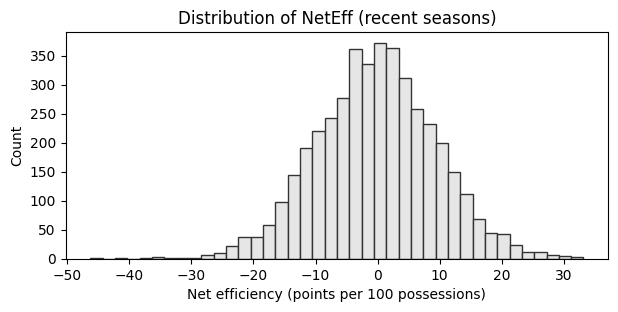

,mean,std,min,max
WinPct,0.494743,0.186287,0.000000,1.000000
MarginPG,-0.199944,6.741154,-33.222222,23.787879
Tempo,69.561563,3.085412,57.659848,84.300000
OffEff,102.744257,6.591475,76.988203,124.701623
DefEff,103.006462,5.748554,83.489734,125.547957
eFG,0.502666,0.031063,0.392722,0.611405
TOV_rate,0.177098,0.022495,0.107157,0.265718
FTR,0.336491,0.051221,0.196037,0.518318
ORB_rate,0.279972,0.044456,0.124726,0.443314


In [36]:
fig, ax = plt.subplots(figsize=(7, 3), dpi=100)

ax.hist(team_season.loc[team_season["Season"] >= 2015, var_to_plot],
        bins=40, ec='.2', fc='.9')
ax.set_xlabel(var_name)
ax.set_ylabel("Count")
ax.set_title("Distribution of %s (recent seasons)"%(var_to_plot))
plt.show()

cols_to_summarize = ["WinPct", "MarginPG", "Tempo", "OffEff", "DefEff",
                     "eFG", "TOV_rate", "FTR", "ORB_rate"]
display(team_season.loc[team_season["Season"] >= 2015,
                        cols_to_summarize].describe().T[["mean", "std", "min", "max"]])

---

## 6. Tournament seeds as a feature (and how to parse them)

The `Seed` column looks like:

- `W01` meaning Region W, seed 1
- `X16a` meaning one of the play-in teams for seed 16 in Region X

We often want the numeric seed $\text{SeedNum} \in \{1,2,\dots,16\}$.


A simple parsing rule:

- extract the two-digit number from the seed string

For example:

- `W01` → 1  
- `X16a` → 16

Why seeds matter:

- Seeds are a human-built summary of team strength and résumé.
- Seeds incorporate information that may not be present in box scores (opponent strength, selection committee choices).

But caution:

- Seeds can also "bake in" subjective decisions.
- If your goal is to learn from performance metrics, seeds can dominate the model.


In [37]:
def parse_seed_num(seed_str):
    """Extract the numeric seed from a Kaggle tournament seed string.

    Kaggle represents seeds with a region letter plus a two-digit seed number,
    sometimes with a trailing play-in letter:

    - 'W01'  -> region W, seed 1
    - 'X16a' -> region X, seed 16 (play-in team a)
    - 'X16b' -> region X, seed 16 (play-in team b)

    Parameters
    ----------
    seed_str : str
        Raw seed string.

    Returns
    -------
    int or np.nan
        Numeric seed (1 to 16) if found, otherwise np.nan.
    """
    m = re.search(r"(\d\d)", str(seed_str))
    if m is None:
        return np.nan
    return int(m.group(1))

def base_seed(seed_str):
    """Remove trailing play-in letters ('a' or 'b') from a seed string.

    Examples:
    - 'X16a' -> 'X16'
    - 'X16b' -> 'X16'
    - 'W01'  -> 'W01'

    This is useful because the main bracket is defined in terms of the *base* seeds
    (e.g., 'X16'), and the play-in game determines which TeamID actually fills that slot.
    """
    s = str(seed_str)
    if s.endswith("a") or s.endswith("b"):
        return s[:-1]
    return s

# Tiny tests (these should always pass)
assert parse_seed_num("W01") == 1
assert parse_seed_num("X16a") == 16
assert base_seed("X16a") == "X16"
assert base_seed("W01") == "W01"

In [38]:
seeds = seeds.copy()
seeds["SeedNum"] = seeds["Seed"].apply(parse_seed_num)
seeds["BaseSeed"] = seeds["Seed"].apply(base_seed)

# Quick peek
display(seeds.sample(10, random_state=5442).sort_values(["Season", "SeedNum"]))


,Season,Seed,TeamID,SeedNum,BaseSeed
66,1986,W03,1231,3,W03
336,1990,X01,1328,1,X01
450,1992,W03,1269,3,W03
696,1995,Z09,1408,9,Z09
858,1998,X11,1304,11,X11
1222,2004,W04,1153,4,W04
1411,2006,Z14,1293,14,Z14
1797,2012,Z05,1307,5,Z05
1775,2012,X16b,1436,16,X16
1930,2014,Z01,1112,1,Z01


### 6.1 Handling play-in seeds (First Four)

When a seed appears twice (for example `W16a` and `W16b`), those teams played a "play-in" game to earn the right to be the `W16` seed in the Round of 64.

For historical seasons, we can resolve the base seed using the play-in results.

For future prediction, we would need to predict the play-in games too (we'll handle that in simulation by simulating those games).


In [39]:
def build_base_seed_to_team(season, seeds_df, tourney_results_df):
    """Build a mapping from BaseSeed (e.g., 'W16') to TeamID for a season.

    The tournament bracket is defined in terms of *seeds* like 'W01', 'W16', etc.
    For play-in seeds, Kaggle uses 'a' and 'b' suffixes:

    - 'W16a' and 'W16b' both correspond to base seed 'W16'
    - the play-in game winner becomes the team that fills the 'W16' slot in the main bracket

    This function resolves that ambiguity using the actual play-in game result from
    the tournament results table.

    Parameters
    ----------
    season : int
        Tournament season to resolve.
    seeds_df : pandas.DataFrame
        Must contain columns: Season, TeamID, BaseSeed (and typically Seed/SeedNum).
    tourney_results_df : pandas.DataFrame
        Tournament game results for all seasons. Must contain: Season, WTeamID, LTeamID.

    Returns
    -------
    seed_map : dict
        Dictionary mapping BaseSeed -> TeamID for the given season, with play-ins resolved.
    """
    s_seeds = seeds_df[seeds_df["Season"] == season].copy()
    s_games = tourney_results_df[tourney_results_df["Season"] == season].copy()

    seed_map = {}

    # Group by base seed (e.g., all teams labeled W16a/W16b get grouped under W16)
    for bseed, grp in s_seeds.groupby("BaseSeed"):
        team_ids = grp["TeamID"].tolist()

        # Most base seeds map to exactly one TeamID
        if len(team_ids) == 1:
            seed_map[bseed] = int(team_ids[0])
            continue

        # For play-ins we expect exactly two TeamIDs and exactly one head-to-head game
        tset = set(team_ids)
        mask = (s_games["WTeamID"].isin(tset)) & (s_games["LTeamID"].isin(tset))
        head_to_head = s_games[mask]

        if head_to_head.shape[0] != 1:
            raise ValueError(
                f"Season {season}, BaseSeed {bseed} has {len(team_ids)} teams but found {head_to_head.shape[0]} play-in games."
            )

        # Winner of the play-in fills the base seed slot
        seed_map[bseed] = int(head_to_head.iloc[0]["WTeamID"])

    return seed_map

In [40]:
demo_season = 2025
demo_map = build_base_seed_to_team(demo_season, seeds, tourney)

# Show a few (especially seeds that often have play-ins like 11 and 16)
keys = sorted([k for k in demo_map.keys() if k.endswith("16") or k.endswith("11")])[:10]
out = pd.DataFrame({"BaseSeed": keys, "TeamID": [demo_map[k]
                                     for k in keys]}).merge(teams, on="TeamID", how="left")
display(out)

,BaseSeed,TeamID,TeamName,FirstD1Season,LastD1Season
0,W11,1433,VCU,1985,2026
1,W16,1291,Mt St Mary's,1989,2026
2,X11,1462,Xavier,1985,2026
3,X16,1188,SIUE,2009,2026
4,Y11,1314,North Carolina,1985,2026
5,Y16,1106,Alabama St,1985,2026
6,Z11,1179,Drake,1985,2026
7,Z16,1313,Norfolk St,1998,2026


---

## 7. Building the supervised learning dataset for tournament games

A tournament game is between two teams. We need a feature vector $x_i$ for that matchup.


### 7.1 A common trick: feature differences

Let $f(t,s)$ be the season feature vector for team $t$ in season $s$.

For a game between Team A and Team B in season $s$, define:

$$
x = f(\text{A}, s) - f(\text{B}, s)
$$


Why this is helpful:

- Swapping A and B flips the sign of $x$, which pairs naturally with a symmetric "Team A wins" label.
- Many sports questions are inherently comparative: we care about *differences* in strength.

We'll also include seed difference:

$$
\Delta\text{Seed} = \text{SeedNum}_A - \text{SeedNum}_B
$$

Interpretation: negative means Team A is the better seed (smaller number).


### 7.2 Defining the label

We represent each game with an ordered pair $(\text{Team1}, \text{Team2})$ defined by `TeamID`:

- `Team1 = min(WTeamID, LTeamID)`
- `Team2 = max(WTeamID, LTeamID)`

Then:

$$
y = 1 \;\;\text{if Team1 won}, \quad y = 0 \;\;\text{otherwise}.
$$


In [41]:
# Example: differences flip sign when teams are swapped
feat_A = np.array([0.60, 5.0])   # imagine [WinPct, NetEff]
feat_B = np.array([0.70, 2.0])

pd.DataFrame({
    "Feature": ["WinPct", "NetEff"],
    "A - B": feat_A - feat_B,
    "B - A": feat_B - feat_A
})

,Feature,A - B,B - A
0,WinPct,-0.1,0.1
1,NetEff,3.0,-3.0


In [42]:
feature_cols = ["WinPct", "MarginPG", "Tempo", "OffEff", "DefEff", "NetEff", "eFG",
                "TOV_rate", "FTR", "ORB_rate"]

g = tourney[tourney["Season"] >= 2003].copy()

g["Team1"] = g[["WTeamID", "LTeamID"]].min(axis=1)
g["Team2"] = g[["WTeamID", "LTeamID"]].max(axis=1)
g["y"] = (g["Team1"] == g["WTeamID"]).astype(int)

seed_map = seeds[["Season", "TeamID", "SeedNum"]].drop_duplicates()
g = g.merge(seed_map.rename(columns={"TeamID": "Team1", "SeedNum": "SeedNum1"}),
            on=["Season", "Team1"], how="left")
g = g.merge(seed_map.rename(columns={"TeamID": "Team2", "SeedNum": "SeedNum2"}),
            on=["Season", "Team2"], how="left")
g["SeedDiff"] = g["SeedNum1"] - g["SeedNum2"]

In [43]:
feats = team_season[["Season", "TeamID"] + feature_cols].copy()
g = g.merge(
    feats.rename(columns={c: f"{c}_1" for c in feature_cols}).rename(columns={"TeamID": "Team1"}),
    on=["Season", "Team1"],
    how="left",
)
g = g.merge(
    feats.rename(columns={c: f"{c}_2" for c in feature_cols}).rename(columns={"TeamID": "Team2"}),
    on=["Season", "Team2"],
    how="left",
)

In [44]:
print(g.shape)
g.head()

(1449, 34)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,Team1,Team2,y,SeedNum1,SeedNum2,SeedDiff,WinPct_1,MarginPG_1,Tempo_1,OffEff_1,DefEff_1,NetEff_1,eFG_1,TOV_rate_1,FTR_1,ORB_rate_1,WinPct_2,MarginPG_2,Tempo_2,OffEff_2,DefEff_2,NetEff_2,eFG_2,TOV_rate_2,FTR_2,ORB_rate_2
0,2003,134,1421,92,1411,84,N,1,1411,1421,0,16,16,0,0.600000,1.966667,70.665000,103.021298,100.238213,2.783085,0.501206,0.215571,0.507841,0.365402,0.448276,-7.241379,70.666379,100.764886,111.012163,-10.247277,0.486339,0.229344,0.368549,0.349705
1,2003,136,1112,80,1436,51,N,0,1112,1436,1,1,16,-15,0.892857,14.964286,77.196429,110.386306,91.001619,19.384687,0.514946,0.191534,0.380435,0.394615,0.655172,4.655172,66.252586,102.325218,95.298817,7.026401,0.491667,0.212353,0.350000,0.372277
2,2003,136,1113,84,1272,71,N,0,1113,1272,1,10,7,3,0.620690,6.793103,69.655172,109.059406,99.306931,9.752475,0.513333,0.200990,0.460606,0.399799,0.793103,8.689655,70.600000,105.548501,93.240207,12.308293,0.496264,0.195370,0.381609,0.373626
3,2003,136,1141,79,1166,73,N,0,1141,1166,1,11,6,5,0.793103,6.103448,72.301724,109.741266,101.299630,8.441636,0.570026,0.252295,0.477749,0.359064,0.878788,14.909091,69.453788,114.093740,92.627537,21.466203,0.568829,0.192410,0.348629,0.337406
4,2003,136,1143,76,1301,74,N,1,1143,1301,1,8,9,-1,0.724138,4.724138,70.925862,105.014950,98.354280,6.660670,0.520258,0.199820,0.332355,0.328298,0.600000,4.400000,67.521667,107.224841,100.708415,6.516427,0.530937,0.210303,0.383750,0.312299


In [45]:
for c in feature_cols:
    g[f"d_{c}"] = g[f"{c}_1"] - g[f"{c}_2"]

model_cols = [f"d_{c}" for c in feature_cols] + ["SeedDiff"]
modeling = g.dropna(subset=model_cols + ["y"]).copy()

X = modeling[model_cols]
y = modeling["y"].astype(int)
seasons = modeling["Season"].astype(int)

In [46]:
print("Modeling rows:", modeling.shape[0])
print("Seasons covered:", seasons.min(), "to", seasons.max())
display(modeling[["Season", "DayNum", "Team1", "Team2", "y", "SeedNum1", "SeedNum2", "SeedDiff"]].head())

Modeling rows: 1449
Seasons covered: 2003 to 2025


,Season,DayNum,Team1,Team2,y,SeedNum1,SeedNum2,SeedDiff
0,2003,134,1411,1421,0,16,16,0
1,2003,136,1112,1436,1,1,16,-15
2,2003,136,1113,1272,1,10,7,3
3,2003,136,1141,1166,1,11,6,5
4,2003,136,1143,1301,1,8,9,-1


---

## 8. Train/test splits

Machine learning is about **generalization**: learning patterns from historical data that hold up on *new* data.

In sports analytics, it's painfully easy to build a model that looks incredible on paper but fails the moment you use it to make real predictions. The most common reason is simple:

**If you train and evaluate on the same data, you're mostly measuring memorization.**


### The forecasting mindset

A clean way to think about March Madness prediction is:

- On Selection Sunday, you have *pre-tournament information* (regular-season performance, seeds, ratings, injuries if available, etc.).
- You want *probabilities for future games* that have not been played yet.


A supervised learning dataset is a collection of examples $(x_i, y_i)$:

- $x_i$ is the feature vector you would know **before** game $i$.
- $y_i \in \{0,1\}$ is the game outcome label. In this notebook:
  - $y_i=1$ means **Team1 wins**
  - $y_i=0$ means **Team1 loses**
- A fitted model outputs $\hat{p}(x_i)$, a probability that Team1 wins.

Because we are predicting **probabilities**, we care about probability-scoring metrics like **log loss** and **Brier score** (Section 3).


### 8.1 Three roles for data: train, validation, test

In an ideal workflow, your data plays three distinct roles:

- **Training set**: data the model is allowed to learn from (fit parameters).
- **Validation set**: data used to make modeling choices (hyperparameters, feature sets, model family).  
  In practice, we often approximate a validation set using **cross-validation**.
- **Test set**: a final, untouched "report card" used once at the end.

The key discipline is:

**Never let test data influence modeling decisions.**

If you tune hyperparameters on the test set, the test set stops being a test.


### 8.2 The sports analytics twist: time, seasons, and leakage

In sports, the main dangers are **time ordering** and **information leakage**.

- **Time ordering:** a random split of games mixes "past" and "future".  
  That can be fine for some scientific questions, but it is usually wrong for forecasting tasks.
- **Leakage:** you accidentally build features using information that would not be known at prediction time (often information that is downstream of the outcome).



A classic March Madness leakage example is *data contamination*:

- You compute "season stats" using games **after** the tournament started (or even including tournament games).
- The resulting features can contain the outcome signal you are trying to predict.

That kind of model can score extremely well in cross-validation but perform poorly when applied to a true out-of-season forecast.


Our default evaluation strategy in this notebook is season-based:

- Train seasons: 2003–2024  
- Test season: 2025  

When tuning hyperparameters, we will use **grouped cross-validation by season** so that each validation fold contains whole seasons.

Before we do that, let's look at two small demonstrations:

1. How leakage can give you "fake" performance.
2. How model flexibility can drive overfitting on the training set.


### 8.3 A tiny leakage example: when you accidentally include the answer key

Imagine we want to predict whether Team1 wins a game.

A legitimate feature might be something like $\text{SeedDiff}$ or $\Delta\text{NetEff}$ — information known before the game.

A **leaky** feature would be something like:

- "Did Team1 win?" (which is literally $y$), or
- "Final score margin," or
- "Tournament round reached" when you're trying to predict tournament wins

These are not available at prediction time, but they can sneak into a dataset if we are not careful about how we construct features.

In the tiny demo below:

- $x$ is a weak-but-real predictor.
- $\text{leak}$ is basically the label $y$ with a tiny bit of noise.

You will see that a model with leakage appears to have near-perfect performance — but it's cheating.


In [47]:
# Leakage demonstration on simulated data
rng = np.random.default_rng(5442)

n = 400

# A modestly predictive feature x
x = rng.normal(size=n)
p_true = sigmoid(0.8 * x)                  # true data-generating probability
y_toy = rng.binomial(1, p_true, size=n)    # outcomes

# A "leaky" feature: almost the label itself (this is not available at prediction time!)
leak = y_toy + 0.01 * rng.normal(size=n)

# Two design matrices:
# 1) legitimate: use only x
# 2) leaky: use x + leak (cheating)
X_legit = pd.DataFrame({"x": x})
X_leaky = pd.DataFrame({"x": x, "leak": leak})

# A simple random split (for this toy demo only)
X_train_legit, X_test_legit, y_train_toy, y_test_toy = train_test_split(
    X_legit, y_toy, test_size=0.35, random_state=5442, stratify=y_toy
)
X_train_leaky, X_test_leaky, _, _ = train_test_split(
    X_leaky, y_toy, test_size=0.35, random_state=5442, stratify=y_toy
)

# Fit the same logistic regression on each
legit_model = LogisticRegression(max_iter=2000).fit(X_train_legit, y_train_toy)
leaky_model = LogisticRegression(max_iter=2000).fit(X_train_leaky, y_train_toy)

p_legit = legit_model.predict_proba(X_test_legit)[:, 1]
p_leaky = leaky_model.predict_proba(X_test_leaky)[:, 1]

print("Test log loss (legitimate features):", log_loss(y_test_toy, p_legit))
print("Test log loss (WITH leakage):       ", log_loss(y_test_toy, p_leaky))

# Sanity check: the leaky model should look "too good to be true"
assert log_loss(y_test_toy, p_leaky) < 0.05, "In this toy setup, leakage should produce near-perfect log loss."

# Interpretation:
# - The leaky model looks amazing because it is using (almost) the outcome itself.
# - At prediction time, we would not have access to 'leak', so this performance is meaningless.


Test log loss (legitimate features): 0.6416908304070628
Test log loss (WITH leakage):        0.04876746479107997


### 8.4 Overfitting demo (why the test set matters)

To make overfitting *feel* real, we'll use a classic toy dataset with a nonlinear boundary (two interlocking "moons").

We will fit decision trees with different maximum depth:

- small depth: simple rules, higher bias, lower variance
- large depth: very flexible, low bias, higher variance

The key lesson:

> Training performance almost always improves with model flexibility, but test performance can get worse.

That is the whole reason we split data.


In [48]:
# Toy overfitting demonstration: decision tree depth
X_moons, y_moons = make_moons(n_samples=600, noise=0.30, random_state=5442)


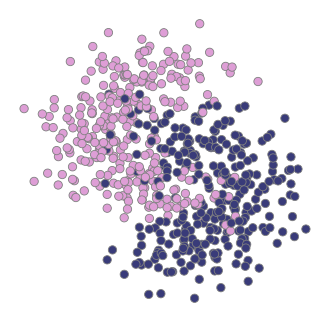

In [49]:
fig, ax = plt.subplots(1,1,figsize=(4,4),dpi=100)
ax.scatter(X_moons[:,1],X_moons[:,0],c=y_moons, cmap='tab20b',ec='.5',lw=0.6)
ax.set_axis_off()
plt.show()

In [50]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=5442, stratify=y_moons
)

In [51]:
depths = list(range(1, 21))
rows = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=5442)
    tree.fit(X_tr, y_tr)

    p_tr = tree.predict_proba(X_tr)[:, 1]
    p_te = tree.predict_proba(X_te)[:, 1]

    rows.append({
        "max_depth": d,
        "accuracy_train": accuracy_score(y_tr, (p_tr >= 0.5).astype(int)),
        "accuracy_test": accuracy_score(y_te, (p_te >= 0.5).astype(int)),
        "logloss_train": log_loss(y_tr, p_tr),
        "logloss_test": log_loss(y_te, p_te),
    })

depth_results = pd.DataFrame(rows)

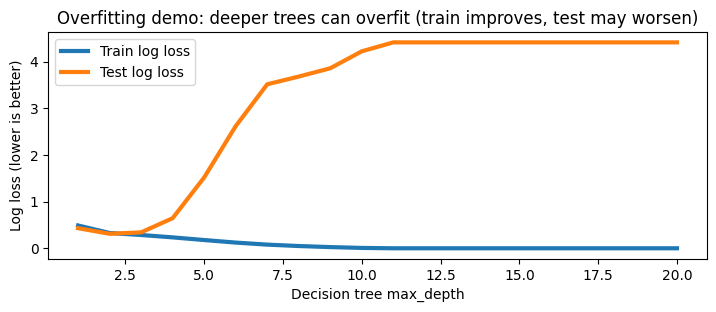

,max_depth,accuracy_train,accuracy_test,logloss_train,logloss_test
0,1,0.804762,0.838889,0.489045,0.430429
1,2,0.892857,0.900000,0.327837,0.310860
2,3,0.892857,0.900000,0.284534,0.341424
3,4,0.900000,0.866667,0.233744,0.645213
4,5,0.923810,0.900000,0.176765,1.518505
5,6,0.940476,0.883333,0.122238,2.617686
6,7,0.961905,0.861111,0.078272,3.514943
7,8,0.971429,0.872222,0.048456,3.680209
8,9,0.985714,0.877778,0.025597,3.858240
9,10,0.995238,0.877778,0.007847,4.221446


In [52]:
fig, ax = plt.subplots(figsize=(8.5, 3), dpi=100)

ax.plot(depth_results["max_depth"], depth_results["logloss_train"], linewidth=3, label="Train log loss")
ax.plot(depth_results["max_depth"], depth_results["logloss_test"], linewidth=3, label="Test log loss")

ax.set_xlabel("Decision tree max_depth")
ax.set_ylabel("Log loss (lower is better)")
ax.set_title("Overfitting demo: deeper trees can overfit (train improves, test may worsen)")

ax.legend()
plt.show()

depth_results.head(10)

In the plot above, the **training log loss** keeps improving as the tree gets deeper. That is not surprising: a deeper tree can carve up the feature space into smaller and smaller regions, eventually memorizing the training set.

The **test log loss** is the reality check. It typically improves at first (the model is capturing real structure), then eventually stops improving or even gets worse (the model is fitting noise).

In practice, we use a **validation procedure** (like cross-validation) to choose model complexity *without touching the test set*. Then we evaluate once on the test set at the end.


In [53]:
test_season = 2025
train_mask = seasons < test_season
test_mask = seasons == test_season

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]
seasons_train = seasons.loc[train_mask]

print("Train games:", X_train.shape[0], " Test games:", X_test.shape[0])
print("Train seasons:", seasons_train.min(), "to", seasons_train.max())


Train games: 1382  Test games: 67
Train seasons: 2003 to 2024


### 8.5 Random split vs season split (a common evaluation trap)

A random split across *all* games can be fine for some questions, but it quietly changes the forecasting task.

For bracket prediction, we want: "Train on past seasons, then predict a future season."

If we randomly split games across all seasons, the training set will typically include games from the same season we are testing on (including the 2025 tournament). That usually makes evaluation look a bit better than it should, because the model is being tested on a distribution it partially trained on.

Below we fit the *same* logistic regression pipeline two ways:

1. **Season split** (forecasting-style): train < 2025, test = 2025  
2. **Random split** (mixed seasons): train/test drawn from all seasons  

We are not doing this because random splits are "evil" — we are doing it to build intuition for why sports analytics often prefers time-aware splits.


In [54]:
quick_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=2000))
])

# (A) Season-based split (forecasting-style)
quick_model.fit(X_train, y_train)
p_season = quick_model.predict_proba(X_test)[:, 1]

metrics_season = {
    "log_loss": log_loss(y_test, p_season),
    "brier": brier_score_loss(y_test, p_season),
    "roc_auc": roc_auc_score(y_test, p_season),
    "accuracy@0.5": accuracy_score(y_test, (p_season >= 0.5).astype(int)),
}

# (B) Random split across all seasons (mixes years)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X, y, test_size=0.25, random_state=5442, stratify=y
)
quick_model.fit(X_tr_r, y_tr_r)
p_rand = quick_model.predict_proba(X_te_r)[:, 1]

metrics_rand = {
    "log_loss": log_loss(y_te_r, p_rand),
    "brier": brier_score_loss(y_te_r, p_rand),
    "roc_auc": roc_auc_score(y_te_r, p_rand),
    "accuracy@0.5": accuracy_score(y_te_r, (p_rand >= 0.5).astype(int)),
}

compare = pd.DataFrame([metrics_season, metrics_rand],
                       index=["Season split (train<2025, test=2025)",
                              "Random split (mixed seasons)"])
compare


,log_loss,brier,roc_auc,accuracy@0.5
"Season split (train<2025, test=2025)",0.481119,0.158188,0.863553,0.746269
Random split (mixed seasons),0.566996,0.195590,0.766377,0.688705


---

## 9. Baselines (always start here)

Before fitting any fancy model, we want simple baselines:

1. **Better seed wins** (deterministic).
2. **Seed-only logistic regression** (probabilistic).

Baselines are not just for humility — they clarify what your extra features actually buy you.


### 9.1 Baseline: predict Team1 wins if Team1 has the better seed

We predict:

$$
\hat{y} = \mathbf{1}[\text{SeedDiff} < 0]
$$

For log loss we need probabilities, so we'll also create a crude probability baseline:

- If Team1 is the better seed: predict $p=0.65$
- Otherwise: predict $p=0.35$

Those numbers are arbitrary; they're just a simple reference point.


In [55]:
yhat_seed = (X_test["SeedDiff"] < 0).astype(int)
p_seed = np.where(X_test["SeedDiff"] < 0, 0.65, 0.35)

baseline = {
    "accuracy": accuracy_score(y_test, yhat_seed),
    "log_loss": log_loss(y_test, p_seed),
    "brier": brier_score_loss(y_test, p_seed),
    "roc_auc": roc_auc_score(y_test, p_seed),
}
display(pd.Series(baseline).to_frame("Seed baseline (test season)"))


,Seed baseline (test season)
accuracy,0.791045
log_loss,0.560134
brier,0.185187
roc_auc,0.805403


### 9.2 Baseline: seed-only logistic regression

We fit:

$$
P(y=1 \mid \Delta\text{Seed}) = \sigma(\beta_0 + \beta_1\,\Delta\text{Seed})
$$

Symbol map for our dataset:

- $y$ is the `y` column (Team1 won).
- $\Delta\text{Seed}$ is the `SeedDiff` feature.

Interpretation:

- If $\beta_1$ is negative, then a larger `SeedDiff` (worse seed for Team1) reduces Team1's win probability.


In [56]:
seed_only = LogisticRegression(solver="lbfgs", max_iter=2000)
seed_only.fit(X_train[["SeedDiff"]].values, y_train.values)

p_test_seed_only = seed_only.predict_proba(X_test[["SeedDiff"]].values)[:, 1]
yhat_test_seed_only = (p_test_seed_only >= 0.5).astype(int)

out = {
    "accuracy": accuracy_score(y_test, yhat_test_seed_only),
    "log_loss": log_loss(y_test, p_test_seed_only),
    "brier": brier_score_loss(y_test, p_test_seed_only),
    "roc_auc": roc_auc_score(y_test, p_test_seed_only),
    "beta0": float(seed_only.intercept_[0]),
    "beta1": float(seed_only.coef_.ravel()[0]),
}
display(pd.Series(out).to_frame("Seed-only logistic regression (test season)"))
print("Odds ratio per +1 SeedDiff:", float(np.exp(out["beta1"])))


,Seed-only logistic regression (test season)
accuracy,0.791045
log_loss,0.491610
brier,0.161033
roc_auc,0.873626
beta0,-0.040488
beta1,-0.157083


Odds ratio per +1 SeedDiff: 0.8546328188279588


In [57]:
sd = np.arange(-15, 16).reshape(-1, 1)
p_sd = seed_only.predict_proba(sd)[:, 1]

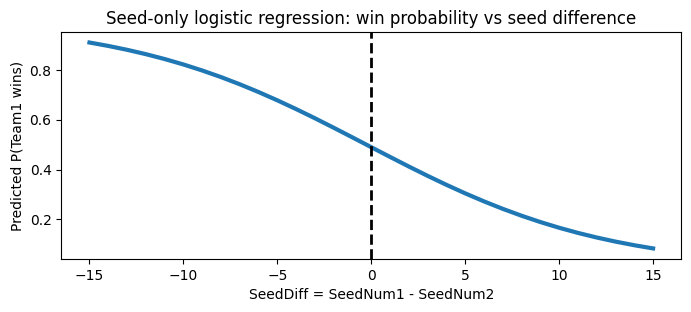

In [58]:
fig, ax = plt.subplots(figsize=(8, 3), dpi=100)

ax.plot(sd.ravel(), p_sd, linewidth=3)
ax.axvline(0, linestyle="--", linewidth=2, color='k')
ax.set_xlabel("SeedDiff = SeedNum1 - SeedNum2")
ax.set_ylabel("Predicted P(Team1 wins)")
ax.set_title("Seed-only logistic regression: win probability vs seed difference")

plt.show()

---

## 10. A first real model: logistic regression with season features + seeds

Logistic regression is a strong starting point for sports outcome modeling because:

- it outputs probabilities
- it's fairly interpretable
- with regularization, it handles correlated features reasonably well


### 10.1 Standardizing features

For a feature column $x$:

$$
x' = \frac{x - \mu}{s}
$$

Definitions:

- $\mu$ is the mean of the feature in the training data.
- $s$ is the standard deviation in the training data.
- $x'$ has mean 0 and standard deviation 1 (on the training set).

We will use `StandardScaler` inside a `Pipeline` so we don't accidentally standardize using test data.


### 10.2 Regularization (gentle version)

With **L2 regularization** (ridge), we minimize:

$$
\text{Objective} = \text{LogLoss} + \lambda \sum_{j=1}^p \beta_j^2
$$

In scikit-learn the hyperparameter is `C = 1/\lambda` (larger `C` means weaker regularization).


**Practical note (runtime):** Cross-validation is one of the most important habits in ML, but it can be computationally expensive if you search over a large hyperparameter grid.

In this notebook we use a **small** grid for `C` and a modest number of season folds so that the notebook runs quickly on typical laptops.

If you want to do a more exhaustive search (more folds, more `C` values, multiple model families), see Appendix E for a deeper discussion of season-aware cross-validation.


In [59]:
# Micro-example: standardization by hand
x_raw = np.array([2.0, 4.0, 6.0, 8.0])
mu = x_raw.mean()
s = x_raw.std(ddof=0)
x_std = (x_raw - mu) / s

pd.DataFrame({"x": x_raw, "x_std": x_std})

,x,x_std
0,2.0,-1.341641
1,4.0,-0.447214
2,6.0,0.447214
3,8.0,1.341641


In [60]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=2000))
])

In [61]:
# A small hyperparameter grid.
# (You can expand this grid in Appendix E if you want a more exhaustive search.)
param_grid = {"logreg__C": np.logspace(-1, 1, 5)}  # C in {0.1, 0.316, 1, 3.16, 10}

In [62]:
# Season-aware cross-validation: keep entire seasons together.
# With ~20+ seasons of training data, 4 folds is a reasonable compromise between
# stability and runtime for classroom work.
cv = GroupKFold(n_splits=4)

In [63]:
search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv.split(X_train, y_train, groups=seasons_train),
    scoring="neg_log_loss",
    n_jobs=1,
    refit=True
)

search.fit(X_train, y_train)

# Inspect CV performance by C (higher is better because this is NEGATIVE log loss)
cv_table = (
    pd.DataFrame(search.cv_results_)[
        ["param_logreg__C", "mean_test_score", "std_test_score", "rank_test_score"]
    ]
    .rename(columns={
        "param_logreg__C": "C",
        "mean_test_score": "mean_neg_log_loss",
        "std_test_score": "std_neg_log_loss",
    })
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)
display(cv_table)

,C,mean_neg_log_loss,std_neg_log_loss,rank_test_score
0,0.1,-0.561118,0.012296,1
1,0.316228,-0.561355,0.012576,2
2,1.0,-0.561569,0.012305,3
3,3.162278,-0.561670,0.011580,4
4,10.0,-0.561871,0.010681,5


In [64]:
print("Best C:", float(search.best_params_["logreg__C"]))
print("Best CV neg log loss:", float(search.best_score_))

best_model = search.best_estimator_

Best C: 0.1
Best CV neg log loss: -0.5611181162683019


### 10.3 Test-season evaluation (2025)

We evaluate on 2025 tournament games:

- Accuracy (threshold 0.5)
- Log loss
- Brier score
- ROC-AUC

Then we inspect:

- a confusion matrix
- an ROC curve
- a calibration curve (do predicted probabilities match empirical frequencies?)


In [65]:
# Probabilistic predictions for the held-out 2025 tournament games
p_test_logreg = best_model.predict_proba(X_test)[:, 1]
yhat_test_logreg = (p_test_logreg >= 0.5).astype(int)

In [66]:
# Store metrics so we can compare to other models later (e.g., random forests)
metrics_logreg = {
    "accuracy": accuracy_score(y_test, yhat_test_logreg),
    "log_loss": log_loss(y_test, p_test_logreg),
    "brier": brier_score_loss(y_test, p_test_logreg),
    "roc_auc": roc_auc_score(y_test, p_test_logreg),
}
display(pd.Series(metrics_logreg).to_frame("Full logistic regression (test season)"))

,Full logistic regression (test season)
accuracy,0.746269
log_loss,0.483057
brier,0.158356
roc_auc,0.865385


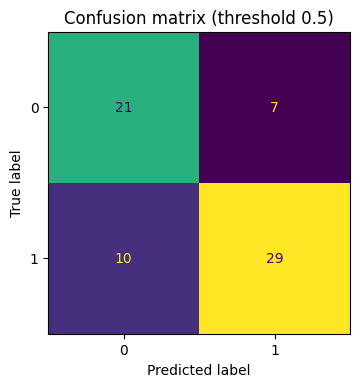

In [67]:
fig, ax = plt.subplots(figsize=(4.5, 4.0), dpi=100)
ConfusionMatrixDisplay.from_predictions(y_test, yhat_test_logreg, ax=ax, colorbar=False)
ax.set_title("Confusion matrix (threshold 0.5)")
plt.show()

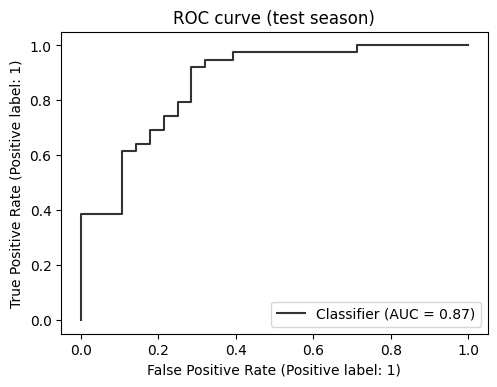

In [68]:
fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=100)
RocCurveDisplay.from_predictions(y_test, p_test_logreg, ax=ax, color='.2')
ax.set_title("ROC curve (test season)")
plt.show()

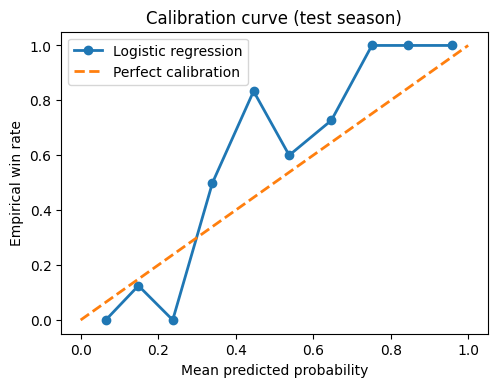

In [69]:
# Calibration curve: do predicted probabilities match empirical frequencies?
frac_pos, mean_pred = calibration_curve(y_test, p_test_logreg, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=100)
ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, label="Logistic regression")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Empirical win rate")
ax.set_title("Calibration curve (test season)")

ax.legend()
plt.show()

---

## 11. Interpreting the logistic regression model

Logistic regression gives a coefficient $\beta_j$ for each feature.

With standardized features, a helpful interpretation is:

- A 1 standard deviation increase in feature $j$ changes the **log-odds** by $\beta_j$.
- It multiplies the odds by $e^{\beta_j}$.

Because we used feature differences:

- If $\beta_j$ is positive, then "Team1 higher than Team2" on that feature increases Team1's win probability.


In [70]:
coefs = best_model.named_steps["logreg"].coef_.ravel()
feat_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    "feature": feat_names,
    "beta": coefs,
    "odds_multiplier_per_1sd": np.exp(coefs),
    "abs_beta": np.abs(coefs),
}).sort_values("abs_beta", ascending=False)

display(coef_df.drop(columns=["abs_beta"]).head(15))


,feature,beta,odds_multiplier_per_1sd
10,SeedDiff,-0.837244,0.432902
1,d_MarginPG,0.276197,1.318107
3,d_OffEff,0.164462,1.178759
0,d_WinPct,-0.148372,0.862111
5,d_NetEff,0.147522,1.158959
8,d_FTR,-0.143455,0.866360
9,d_ORB_rate,0.136620,1.146392
2,d_Tempo,-0.068887,0.933432
6,d_eFG,-0.060279,0.941502
7,d_TOV_rate,-0.052279,0.949064


### 11.1 A single-game walk-through (symbols → code)

For a specific game $i$, logistic regression computes:

$$
z_i = \beta_0 + x_i^\top\beta
\quad\Rightarrow\quad
p_i = \sigma(z_i)
$$

Definitions:

- $x_i$ is the feature vector for game $i$ (our `X_test` row).
- $\beta$ is the coefficient vector learned from training data.
- $z_i$ is the log-odds score.
- $p_i$ is the predicted probability Team1 wins.

We'll pick one test-season game and compute these by hand to make the mapping explicit.


In [71]:
i = 0
x_row = X_test.iloc[i:i+1]
y_true = int(y_test.iloc[i])

scaler = best_model.named_steps["scaler"]
logreg = best_model.named_steps["logreg"]

x_scaled = (x_row.values - scaler.mean_) / scaler.scale_
z_manual = logreg.intercept_[0] + float(x_scaled @ logreg.coef_.ravel())
p_manual = sigmoid(z_manual)

p_model = float(best_model.predict_proba(x_row)[:, 1])
z_model = float(best_model.decision_function(x_row))

In [72]:
print("True label y:", y_true)
print("z_manual:", z_manual, " z_model:", z_model)
print("p_manual:", p_manual, " p_model:", p_model)

contrib = (x_scaled.ravel() * logreg.coef_.ravel())
contrib_df = pd.DataFrame({
    "feature": X_test.columns,
    "x_scaled": x_scaled.ravel(),
    "beta": logreg.coef_.ravel(),
    "contribution_to_z": contrib
}).sort_values("contribution_to_z", key=np.abs, ascending=False)

display(contrib_df.head(10))

True label y: 1
z_manual: 0.3290004009938782  z_model: 0.3290004009938782
p_manual: 0.5815161391467911  p_model: 0.5815161391467911


,feature,x_scaled,beta,contribution_to_z
1,d_MarginPG,0.731304,0.276197,0.201984
8,d_FTR,0.925675,-0.143455,-0.132793
7,d_TOV_rate,-2.442362,-0.052279,0.127684
0,d_WinPct,0.758690,-0.148372,-0.112568
5,d_NetEff,0.756010,0.147522,0.111528
6,d_eFG,-1.364855,-0.060279,0.082272
9,d_ORB_rate,0.363715,0.136620,0.049691
4,d_DefEff,-0.902524,-0.039223,0.035399
2,d_Tempo,0.511773,-0.068887,-0.035254
3,d_OffEff,0.208489,0.164462,0.034289


---

## 12. Random forests: a workhorse model for sports prediction

So far we have emphasized **logistic regression** because it is simple, interpretable, and a great baseline.

However, logistic regression makes a strong modeling assumption:

> the log-odds of Team1 winning is a *linear* function of the features.

That can be a very good approximation, but real matchups can include **nonlinearities** and **interactions**:

- maybe extreme tempo interacts with turnover rate
- maybe the value of offensive rebounding differs for high- vs low-efficiency shooting teams
- maybe seeds matter differently for strong vs weak conferences (not modeled here, but a common idea)

A **random forest** is one of the most commonly used "next-step" models because it can capture nonlinear patterns with relatively little feature engineering.

In this section we will:

- build intuition from the ground up (trees → bagging → random forests)
- connect the math to the scikit-learn API
- fit a random forest to the March Madness tournament-game dataset and compare to logistic regression

We will stay gentle on the theory, but we will be very explicit about what each quantity means and why the formulas look the way they do.


### 12.1 Decision trees: the basic building block

A **decision tree** repeatedly asks simple questions like:

- Is $\Delta\text{NetEff} > 5$?
- Is $\Delta\text{Tempo} < 0$?
- Is $\text{SeedDiff} \le -3$?

Each question *splits* the dataset into two groups. After several splits, we end up in a **leaf** node that contains a subset of training games that "look similar" under those questions.

For **binary classification** (win/loss), a leaf can predict a probability:

$$
\hat{p}_{\text{leaf}} = \frac{\#\{y_i=1\ \text{in leaf}\}}{\#\{\text{examples in leaf}\}}.
$$

Definitions:

- $y_i \in \{0,1\}$ is the game outcome label (1 = Team1 win).
- The numerator counts how many training games in the leaf were wins.
- The denominator counts how many training games fell into that leaf.

This makes sense: if 18 out of 25 similar games were Team1 wins, we might predict $\hat{p}=18/25=0.72$ for a new game that lands in the same leaf.

#### How does a tree decide where to split?

Trees choose splits that make the child nodes "purer" (more dominated by wins or losses). A common impurity measure is **Gini impurity**.

For a node $t$ with class probabilities $p_1(t), p_0(t)$ (for classes 1 and 0):

$$
G(t) = 1 - \left(p_1(t)^2 + p_0(t)^2\right).
$$

Because $p_0(t)=1-p_1(t)$ in binary classification, you will often see:

$$
G(t) = 2p(1-p),
$$

where $p=p_1(t)$ is the probability of class 1 in that node.

Interpretation:

- If a node is perfectly pure, say $p=1$ or $p=0$, then $G(t)=0$.
- If a node is maximally mixed, $p=0.5$, then $G(t)=0.5$.

Let's do a tiny numeric example and compute it in code.


In [73]:
# Micro-example: Gini impurity for a binary node
def gini_binary(p):
    """Gini impurity for binary classification.

    Parameters
    ----------
    p : float
        Probability of class 1 in the node (0 <= p <= 1).

    Returns
    -------
    float
        Gini impurity G = 2 p (1-p).
    """
    p = float(p)
    assert 0.0 <= p <= 1.0
    return 2 * p * (1 - p)

In [74]:
ps = [0.0, 0.2, 0.5, 0.8, 1.0]
pd.DataFrame({
    "p = P(y=1 in node)": ps,
    "Gini G = 2p(1-p)": [gini_binary(p) for p in ps],
})


,p = P(y=1 in node),Gini G = 2p(1-p)
0,0.0,0.00
1,0.2,0.32
2,0.5,0.50
3,0.8,0.32
4,1.0,0.00


#### Impurity reduction from a split

Suppose a candidate split divides a parent node into a left child $L$ and a right child $R$.

A standard split criterion is the **weighted impurity after the split**:

$$
G_{\text{after}} = \frac{n_L}{n}\,G(L) + \frac{n_R}{n}\,G(R),
$$

where:

- $n$ is the number of training examples in the parent node,
- $n_L$ is the number of examples sent left,
- $n_R$ is the number of examples sent right,
- $G(\cdot)$ is the impurity (here: Gini).

The **impurity reduction** is then:

$$
\Delta G = G(\text{parent}) - G_{\text{after}}.
$$

Intuition:

- A "good" split creates children that are purer than the parent, so $G_{\text{after}}$ is smaller and $\Delta G$ is larger.
- A "bad" split barely changes purity, so $\Delta G$ is close to 0.

Tiny example (with counts):

- Parent node: 20 games, 10 wins and 10 losses $\Rightarrow p=0.5$.
- Left child: 10 games, 9 wins and 1 loss $\Rightarrow p=0.9$.
- Right child: 10 games, 1 win and 9 losses $\Rightarrow p=0.1$.

Let's compute $\Delta G$ in code.


In [75]:
# Micro-example: impurity reduction from a split (using counts)
def gini_from_counts(n1, n0):
    """Gini impurity from counts of class 1 and class 0."""
    n1 = float(n1)
    n0 = float(n0)
    n = n1 + n0
    assert n > 0
    p = n1 / n
    return gini_binary(p)

In [76]:
# Parent node: 10 wins, 10 losses
G_parent = gini_from_counts(n1=10, n0=10)

# Left child: 9 wins, 1 loss
G_left = gini_from_counts(n1=9, n0=1)

# Right child: 1 win, 9 losses
G_right = gini_from_counts(n1=1, n0=9)

n_parent = 20
n_left = 10
n_right = 10

G_after = (n_left / n_parent) * G_left + (n_right / n_parent) * G_right
delta_G = G_parent - G_after

pd.DataFrame({
    "node": ["parent", "left", "right", "after (weighted)", "delta_G"],
    "gini": [G_parent, G_left, G_right, G_after, delta_G],
})


,node,gini
0,parent,0.50
1,left,0.18
2,right,0.18
3,after (weighted),0.18
4,delta_G,0.32


### 12.2 Why single trees can be risky: instability (high variance)

Decision trees are flexible, which is great — but flexibility often comes with **variance**.

A tree can change a lot if the training data changes a little. In sports terms:

- a few one-possession games flipping outcomes can change the learned splits
- a couple of injuries can change late-season box scores
- small-sample features can wobble

This instability is one reason trees are usually not the final model.

A standard fix is to average many trees built on *slightly different* training datasets. That idea is called **bagging**.


### 12.3 Bagging: averaging reduces variance

Bagging = **B**ootstrap **Agg**regat**ing**.

Algorithm idea:

1. Sample a *bootstrap* training set (sample with replacement from the original training data).
2. Fit a model (often a tree) on that bootstrap sample.
3. Repeat $B$ times and average the predictions.

If $\hat{p}^{(b)}(x)$ is the probability predicted by the $b$-th tree, bagging predicts:

$$
\hat{p}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^B \hat{p}^{(b)}(x).
$$

Definitions:

- $B$ is the number of bootstrap models (in scikit-learn, this is often `n_estimators`).
- $\hat{p}^{(b)}(x)$ is the predicted probability from model $b$.

Why averaging helps (variance intuition):

If we average many noisy estimates, the noise tends to cancel out.

A clean math version (not a proof, just intuition):

- Suppose each estimator has variance $\sigma^2$.
- Suppose any pair has correlation $\rho$ (how similar the estimators are).

Then the variance of the average is approximately:

$$
\text{Var}(\text{average}) \approx \frac{\sigma^2}{B}\left(1 + (B-1)\rho\right).
$$

Interpretation:

- If $\rho=0$ (independent estimators), variance shrinks like $\sigma^2/B$.
- If $\rho=1$ (perfectly correlated estimators), averaging does nothing.

This is the key insight behind random forests:

> We want trees that are not only accurate, but also not too correlated.

Let's simulate this variance reduction on a toy example.


In [77]:
# Micro-simulation: variance reduction from averaging (bagging intuition)

def empirical_var_of_average(B, rho, n_sims=5000, rng=None):
    """Empirically estimate Var(mean of B correlated N(0,1) variables).

    We generate correlated variables using a one-factor construction:
        Z_b = sqrt(rho) * U + sqrt(1-rho) * E_b
    where U is shared across b and E_b are independent.

    Parameters
    ----------
    B : int
        Number of estimators being averaged.
    rho : float
        Pairwise correlation in [0, 1).
    n_sims : int
        Number of Monte Carlo simulations.
    rng : np.random.Generator
        Random number generator.

    Returns
    -------
    float
        Empirical variance of the average.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    assert B >= 1
    assert 0.0 <= rho < 1.0

    U = rng.normal(size=n_sims)                      # shared component
    E = rng.normal(size=(n_sims, B))                 # idiosyncratic components
    Z = np.sqrt(rho) * U[:, None] + np.sqrt(1 - rho) * E
    avg = Z.mean(axis=1)
    return avg.var()

In [78]:
Bs = [1, 2, 5, 10, 25, 50, 100]
rhos = [0.0, 0.2, 0.8]

rows = []
for rho in rhos:
    for B in Bs:
        rows.append({"rho": rho, "B": B, "Var(avg)": empirical_var_of_average(B, rho, n_sims=8000, rng=RNG)})

bag_df = pd.DataFrame(rows)

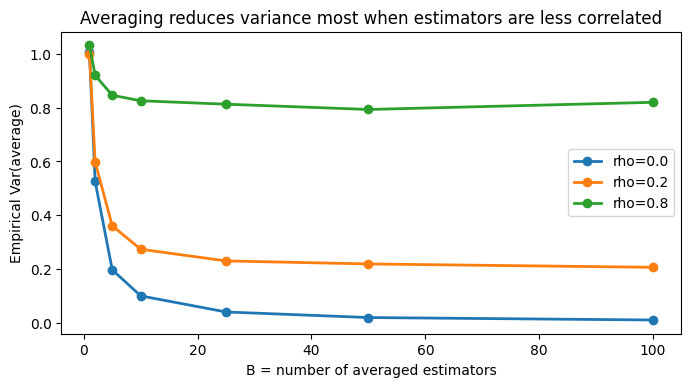

rho,0.0,0.2,0.8
B,,,
1,1.006064,1.000960,1.031651
2,0.525486,0.598068,0.920269
5,0.196874,0.360587,0.846354
10,0.099955,0.273474,0.825849
25,0.040024,0.229991,0.813052
50,0.019332,0.218738,0.793472
100,0.010203,0.206202,0.820113


In [79]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
for rho in rhos:
    sub = bag_df[bag_df["rho"] == rho]
    ax.plot(sub["B"], sub["Var(avg)"], marker="o", linewidth=2, label=f"rho={rho}")

ax.set_xlabel("B = number of averaged estimators")
ax.set_ylabel("Empirical Var(average)")
ax.set_title("Averaging reduces variance most when estimators are less correlated")
ax.legend()
plt.show()

bag_df.pivot(index="B", columns="rho", values="Var(avg)")

### 12.4 Random forests: bagged trees + random feature selection

A **random forest** is essentially:

- bagging (bootstrap sampling of training games)
- decision trees (high-variance base learner)
- **random feature subsampling** at each split (to reduce correlation across trees)

At each split, instead of considering *all* $p$ features, a random forest considers only a random subset of size $m$.

- In scikit-learn, this is controlled by `max_features`.
- Common defaults:
  - classification: `max_features="sqrt"` (so $m \approx \sqrt{p}$)
  - regression: `max_features=1.0` (all features)

#### Random forest probabilities as "vote fractions"

For a binary outcome, each tree can "vote" for class 1 or 0. Let $T_b(x) \in \{0,1\}$ be tree $b$'s predicted class for input $x$. Then the random forest probability is:

$$
\hat{p}_{\text{RF}}(x) = \frac{1}{B}\sum_{b=1}^B \mathbf{1}[T_b(x)=1].
$$

Definitions:

- $B$ = number of trees (`n_estimators`)
- $\mathbf{1}[\cdot]$ = indicator function (1 if true, 0 otherwise)

This is literally "the fraction of trees voting for Team1 to win."

Tiny micro-example: if 7 out of 10 trees vote for class 1, then $\hat{p}=0.7$.


In [80]:
# Micro-example: random forest probability as a vote fraction
votes = np.array([1, 1, 0, 1, 0, 1, 1, 1, 0, 1])  # 10 trees voting
p_hat = votes.mean()

pd.DataFrame({
    "B (trees)": [len(votes)],
    "votes_for_class_1": [votes.sum()],
    "p_hat = votes/B": [p_hat],
})


,B (trees),votes_for_class_1,p_hat = votes/B
0,10,7,0.7


#### 12.4.1 Bootstrapping and out-of-bag (OOB) samples

A subtle but important fact about bootstrap sampling:

- Each tree is trained on a bootstrap sample of size $n$ drawn **with replacement** from the $n$ training games.
- Some training games will appear multiple times in a tree's bootstrap sample.
- Some training games will not appear at all for that tree.

For a fixed training example $i$, the probability it is **not** selected in one bootstrap draw is $1 - 1/n$.  
Because we draw $n$ times (with replacement), the probability it is **never** selected is:

$$
P(i \text{ is OOB}) = \left(1 - \frac{1}{n}\right)^n.
$$

As $n$ grows, this approaches $e^{-1} \approx 0.368$.

So, for each tree, about:

- $36.8\%$ of training examples are **out-of-bag** (OOB) for that tree
- $63.2\%$ are **in-bag** (used to fit that tree)

This matters because OOB examples behave like a built-in validation set:

- a tree never saw its OOB games during training
- we can predict those OOB games and estimate performance without an explicit validation split

In scikit-learn, `RandomForestClassifier(oob_score=True)` computes an OOB accuracy score for this reason.

Let's confirm the $0.632/0.368$ fact with a quick simulation.


In [81]:
# Micro-example: bootstrap "unique fraction" and OOB fraction
rng = np.random.default_rng(5442)

n = 1000
B = 300

unique_fracs = []
oob_fracs = []

for _ in range(B):
    sample = rng.integers(0, n, size=n)     # bootstrap indices (with replacement)
    unique = np.unique(sample)
    unique_fracs.append(len(unique) / n)
    oob_fracs.append(1 - len(unique) / n)

theory_oob = (1 - 1/n) ** n

In [82]:
pd.DataFrame({
    "quantity": [
        "mean unique fraction (in-bag share)",
        "mean OOB fraction",
        "theory OOB (1 - 1/n)^n",
        "asymptotic e^{-1}",
    ],
    "value": [
        float(np.mean(unique_fracs)),
        float(np.mean(oob_fracs)),
        float(theory_oob),
        float(np.exp(-1)),
    ]
})


,quantity,value
0,mean unique fraction (in-bag share),0.632300
1,mean OOB fraction,0.367700
2,theory OOB (1 - 1/n)^n,0.367695
3,asymptotic e^{-1},0.367879


#### 12.4.2 Hyperparameters you should understand for random forests

Random forests have many knobs. Most of the time, a few of them matter a lot:

- `n_estimators` ($B$): number of trees.  
  More trees usually improves performance smoothly (and stabilizes probabilities), but costs computation.

- `max_features` ($m$): number of features considered at each split.  
  Smaller $m$ increases randomness and reduces correlation across trees (helping variance reduction), but can make each tree weaker.

- `min_samples_leaf`: minimum number of training examples allowed in a leaf.  
  Larger values produce *smoother* probability estimates (less extreme 0/1 leaves) and often help calibration.

- `max_depth`: maximum depth of each tree (optional).  
  Limiting depth can reduce overfitting and speed up training.

- `bootstrap`: whether to use bootstrap samples (default `True`).  
  This is required for out-of-bag (OOB) scoring.

When you're new to random forests, it is a good habit to ask two questions whenever you change a hyperparameter:

1. Does this change make individual trees **more flexible** or **less flexible**?
2. Does this change make trees **more correlated** or **less correlated**?

Those two questions connect directly to bias/variance intuition and help you tune forests without guesswork.


### 12.5 Optional visual intuition: trees vs random forests on a nonlinear toy problem

This is optional, but it is often the fastest way to "get" what random forests do.

We will reuse the two-moons toy dataset and compare:

- logistic regression (linear boundary)
- a single decision tree (can be very wiggly)
- a random forest (averages many trees, smoother boundary)

Even though this is not basketball data, the *model behavior* carries over.


In [83]:
def plot_decision_boundary_2d(model, X, y, ax, title, grid_step=0.02):
    """Plot a 2D probability surface for a fitted classifier.

    Parameters
    ----------
    model : fitted classifier
        Must support predict_proba(X) -> probabilities.
    X : np.ndarray, shape (n, 2)
        Two-dimensional feature matrix.
    y : np.ndarray, shape (n,)
        Binary labels.
    ax : matplotlib Axes
        Axes to plot on.
    title : str
        Plot title.
    grid_step : float
        Grid resolution (smaller = smoother, but slower).

    Notes
    -----
    - We intentionally avoid specifying colors; matplotlib defaults are fine.
    - The background shows the predicted P(y=1) over the feature space.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    assert X.ndim == 2 and X.shape[1] == 2

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predicted probability of class 1 on the grid
    zz = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=20, alpha=0.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=15, alpha=0.9, cmap='tab20', ec='.2')

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


In [84]:
# Fit 3 models on the moons data and visualize their decision boundaries
X_moons, y_moons = make_moons(n_samples=600, noise=0.30, random_state=5442)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=5442, stratify=y_moons
)

# Logistic regression (linear boundary)
logreg_moons = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=2000))
])
logreg_moons.fit(X_tr, y_tr)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=2000))])

In [85]:
# Single tree (can overfit)
tree_moons = DecisionTreeClassifier(max_depth=8, random_state=5442)
tree_moons.fit(X_tr, y_tr)

# Random forest (averaging many trees)
rf_moons = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=3,
    random_state=5442,
)
rf_moons.fit(X_tr, y_tr)

RandomForestClassifier(max_features='sqrt', min_samples_leaf=3,
                       n_estimators=300, random_state=5442)

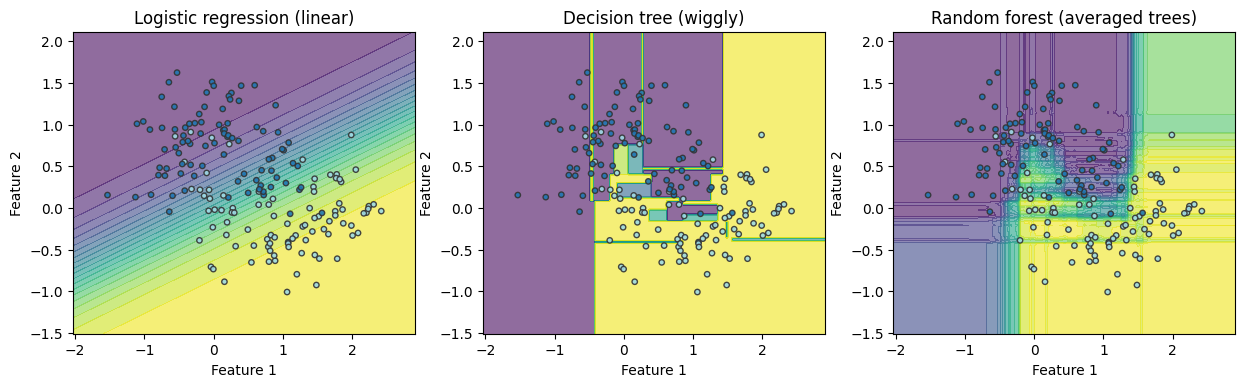

In [86]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

plot_decision_boundary_2d(logreg_moons, X_te, y_te, axes[0], "Logistic regression (linear)")
plot_decision_boundary_2d(tree_moons, X_te, y_te, axes[1], "Decision tree (wiggly)")
plot_decision_boundary_2d(rf_moons, X_te, y_te, axes[2], "Random forest (averaged trees)")

plt.show()

In [87]:
# Quick metric comparison on the test split
models = {
    "logreg": logreg_moons,
    "tree": tree_moons,
    "rf": rf_moons,
}
rows = []
for name, m in models.items():
    p = m.predict_proba(X_te)[:, 1]
    rows.append({
        "model": name,
        "log_loss": log_loss(y_te, p),
        "roc_auc": roc_auc_score(y_te, p),
        "accuracy@0.5": accuracy_score(y_te, (p >= 0.5).astype(int)),
    })
pd.DataFrame(rows).sort_values("log_loss")

,model,log_loss,roc_auc,accuracy@0.5
2,rf,0.246754,0.960370,0.922222
0,logreg,0.350582,0.925185,0.844444
1,tree,3.680209,0.889753,0.872222


### 12.6 Random forest for March Madness game prediction

Now we apply the random forest idea to our actual tournament-game dataset.

Key practical points:

- Random forests **do not require feature scaling**.
- They can handle nonlinearities and interactions automatically.
- They are typically robust, but can still overfit if trees are too deep or leaves are too small.

We will fit a baseline forest with reasonable "anti-overfitting" defaults:

- `min_samples_leaf` > 1 (each leaf must contain multiple training games)
- `max_features="sqrt"` (random feature subsets)
- a moderately large number of trees (`n_estimators`)

Then we will evaluate on the held-out 2025 season, exactly like we did for logistic regression.


In [88]:
rf_model = RandomForestClassifier(
    n_estimators=600,           # number of trees (B in the equations above)
    max_features="sqrt",        # m ~ sqrt(p) features considered per split
    min_samples_leaf=5,         # larger leaf size = smoother, less overfit trees
    random_state=5442,
    n_jobs=1,
    oob_score=True              # out-of-bag accuracy estimate (training-side check)
)

rf_model.fit(X_train, y_train)

# Predicted probabilities for the held-out 2025 tournament games
p_test_rf = rf_model.predict_proba(X_test)[:, 1]
yhat_test_rf = (p_test_rf >= 0.5).astype(int)

metrics_rf = {
    "accuracy": accuracy_score(y_test, yhat_test_rf),
    "log_loss": log_loss(y_test, p_test_rf),
    "brier": brier_score_loss(y_test, p_test_rf),
    "roc_auc": roc_auc_score(y_test, p_test_rf),
    "oob_score (train)": getattr(rf_model, "oob_score_", np.nan),
}

In [89]:
display(pd.Series(metrics_rf).to_frame("Random forest (test season)"))

,Random forest (test season)
accuracy,0.791045
log_loss,0.479404
brier,0.155426
roc_auc,0.870879
oob_score (train),0.673661


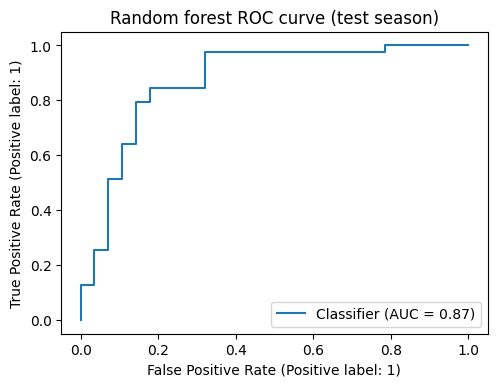

In [90]:
fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=100)
RocCurveDisplay.from_predictions(y_test, p_test_rf, ax=ax)
ax.set_title("Random forest ROC curve (test season)")
plt.show()

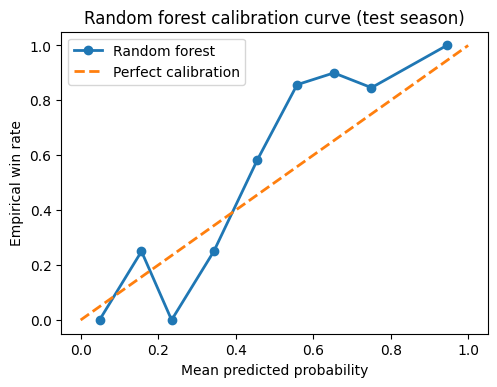

In [91]:
frac_pos, mean_pred = calibration_curve(y_test, p_test_rf, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=100)

ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, label="Random forest")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Empirical win rate")
ax.set_title("Random forest calibration curve (test season)")
ax.legend()

plt.show()

### 12.7 Logistic regression vs random forest (what changed?)

A good habit in applied ML is to compare models **side-by-side** using the same test set.

Below we collect the key metrics from:

- the tuned logistic regression (`metrics_logreg`)
- the random forest (`metrics_rf`)

Interpretation reminders:

- **Log loss**: punishes confident wrong probabilities (lower is better)
- **Brier score**: squared error on probabilities (lower is better)
- **ROC-AUC**: ranking quality (higher is better)
- **Accuracy**: depends on the 0.5 threshold and is often not the main goal


After we compare models, we will pick **one** model to use downstream for:

- error analysis ("what surprised the model?")
- bracket simulation

To keep the workflow simple, we choose the model with lower **test-season log loss** and store it as `final_model`.


In [92]:
# --- Compare metrics in one table (when both models are available) ---
if (metrics_logreg is not None) and (metrics_rf is not None):
    comp = pd.DataFrame({
        "Logistic regression": pd.Series(metrics_logreg),
        "Random forest": pd.Series(metrics_rf),
    })

    # Put test metrics first, then training-side diagnostic like oob_score
    ordered = ["log_loss", "brier", "roc_auc", "accuracy", "oob_score (train)"]
    comp = comp.reindex([k for k in ordered if k in comp.index])
    display(comp)

,Logistic regression,Random forest
log_loss,0.483057,0.479404
brier,0.158356,0.155426
roc_auc,0.865385,0.870879
accuracy,0.746269,0.791045
oob_score (train),NaN,0.673661


In [93]:
# --- Choose one model to use downstream ---
# We will use the model with lower **test-season log loss** when both are available.
# (This is a simple model-selection rule for the classroom; in production you would
# usually use cross-validation, a rolling backtest, or multiple seasons held out.)
final_model = None
final_model_name = None
p_test_final = None

if (metrics_logreg is not None) and (metrics_rf is not None):
    if metrics_rf["log_loss"] <= metrics_logreg["log_loss"]:
        final_model = rf_model
        final_model_name = "Random forest"
        p_test_final = p_test_rf
    else:
        final_model = best_model
        final_model_name = "Logistic regression"
        p_test_final = p_test_logreg
elif (rf_model is not None) and (p_test_rf is not None):
    final_model = rf_model
    final_model_name = "Random forest"
    p_test_final = p_test_rf
elif (best_model is not None) and (p_test_logreg is not None):
    final_model = best_model
    final_model_name = "Logistic regression"
    p_test_final = p_test_logreg
else:
    raise ValueError("No fitted model found for downstream analysis.")

print("Downstream model choice:", final_model_name)

Downstream model choice: Random forest


### 12.8 Interpreting a random forest: feature importance (with caveats)

Random forests are less interpretable than logistic regression coefficients, but we can still learn something about what the model is using.

#### Impurity-based feature importance (fast, but can be biased)

scikit-learn reports `feature_importances_`, based on how much each feature decreases impurity across the forest.

Caveats (important in sports analytics):

- continuous features with many possible split points can look artificially important
- correlated features can "share credit" in unintuitive ways
- importances reflect the *model's behavior*, not necessarily causal importance

We will still look at them because they are a useful first diagnostic.


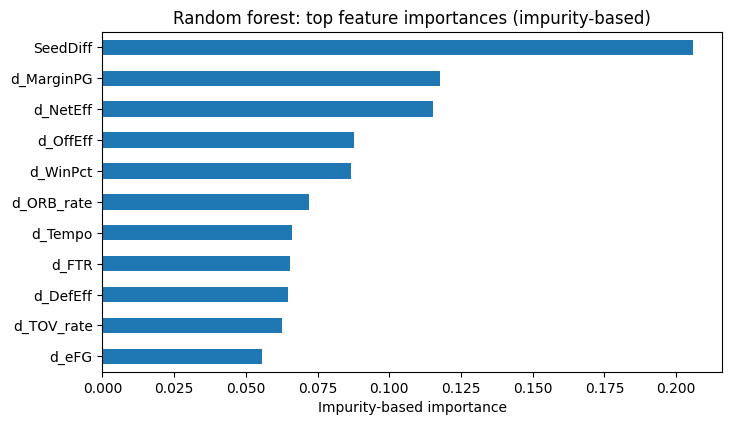

SeedDiff      0.205799
d_MarginPG    0.117718
d_NetEff      0.115344
d_OffEff      0.087825
d_WinPct      0.086808
d_ORB_rate    0.072057
d_Tempo       0.066203
d_FTR         0.065435
d_DefEff      0.064727
d_TOV_rate    0.062538
d_eFG         0.055545
dtype: float64

In [94]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)
importances.head(12).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Impurity-based importance")
ax.set_title("Random forest: top feature importances (impurity-based)")
plt.show()

importances.head(12)


#### Permutation importance (slower, often more reliable)

Permutation importance asks a cleaner question:

> If we randomly shuffle one feature column in the test set (breaking its relationship to the outcome),
> how much does the model's performance degrade?

This is closer to "how much does the model *need* this feature to predict well?"

We will compute permutation importance on the held-out 2025 test season using log loss as the scoring metric.


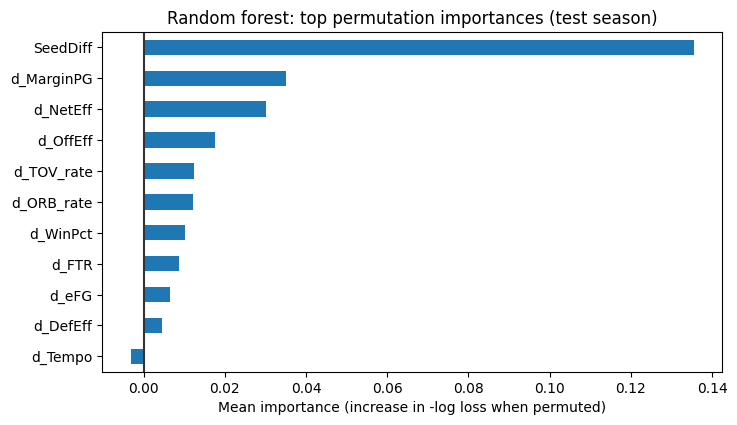

SeedDiff      0.135587
d_MarginPG    0.034939
d_NetEff      0.030092
d_OffEff      0.017579
d_TOV_rate    0.012450
d_ORB_rate    0.012242
d_WinPct      0.010211
d_FTR         0.008737
d_eFG         0.006529
d_DefEff      0.004458
d_Tempo      -0.003235
dtype: float64

In [95]:
# Permutation importance uses a scoring function;
### for log loss we want *negative* log loss in sklearn conventions.
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="neg_log_loss",
    n_repeats=30,
    random_state=5442,
    n_jobs=1,
)

perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=100)
perm_imp.head(12).sort_values().plot(kind="barh", ax=ax)
ax.axvline(0, color='.2')
ax.set_xlabel("Mean importance (increase in -log loss when permuted)")
ax.set_title("Random forest: top permutation importances (test season)")
plt.show()

perm_imp.head(12)

### 12.9 Optional: calibrating random forest probabilities

Random forests often produce decent probabilities, but they are not guaranteed to be well-calibrated.

If calibration matters (and for bracket simulation it often does), we can calibrate:

- **Platt scaling** (logistic calibration): `method="sigmoid"`
- **Isotonic regression**: `method="isotonic"` (more flexible, but needs more data)

We should fit the calibration model using cross-validation **within the training seasons** so we do not leak test information.

This is optional because it adds computational overhead.


In [96]:
# Calibrate the random forest using grouped CV (season-aware)
rf_base = RandomForestClassifier(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=5,
    random_state=5442,
    n_jobs=1,
)

# CalibratedClassifierCV will refit rf_base inside the CV folds
cal = CalibratedClassifierCV(
    base_estimator=rf_base,
    method="sigmoid",  # try "isotonic" as an alternative (often needs more data)
    cv=GroupKFold(n_splits=5).split(X_train, y_train, groups=seasons_train),
)

cal.fit(X_train, y_train)

CalibratedClassifierCV(base_estimator=RandomForestClassifier(max_features='sqrt',
                                                             min_samples_leaf=5,
                                                             n_estimators=600,
                                                             n_jobs=1,
                                                             random_state=5442),
                       cv=<generator object _BaseKFold.split at 0x7fd5b0873cf0>)

In [97]:
p_test_cal = cal.predict_proba(X_test)[:, 1]

metrics_cal = {
    "log_loss": log_loss(y_test, p_test_cal),
    "brier": brier_score_loss(y_test, p_test_cal),
    "roc_auc": roc_auc_score(y_test, p_test_cal),
    "accuracy@0.5": accuracy_score(y_test, (p_test_cal >= 0.5).astype(int)),
}
display(pd.Series(metrics_cal).to_frame("Calibrated random forest (test season)"))

,Calibrated random forest (test season)
log_loss,0.488307
brier,0.157136
roc_auc,0.870879
accuracy@0.5,0.805970


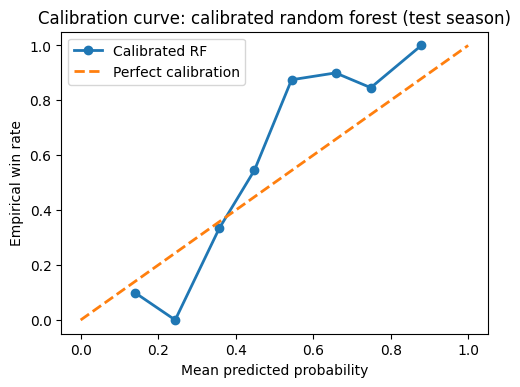

In [98]:
frac_pos, mean_pred = calibration_curve(y_test, p_test_cal, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(5.5, 4.0), dpi=100)

ax.plot(mean_pred, frac_pos, marker="o", linewidth=2, label="Calibrated RF")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Perfect calibration")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Empirical win rate")
ax.set_title("Calibration curve: calibrated random forest (test season)")

ax.legend()
plt.show()

---

## 13. Diagnostics: what games surprised the model?

A useful way to learn from a model is to look at its **largest surprises**:

- games where the model was very confident and wrong
- games where the model predicted a near coin flip

These are often:

- true "upsets"
- matchups where our feature set is missing key information (injuries, matchup styles, late-season changes)
- artifacts of limited features (no opponent adjustment)

We'll list a few examples from the 2025 test season.


In [99]:
test_games = modeling.loc[test_mask].copy()
test_games["p_team1_win"] = p_test_final
test_games["y"] = y_test.values

test_games = test_games.merge(teams.rename(columns={"TeamID": "Team1", "TeamName": "Team1Name"}),
                              on="Team1", how="left")
test_games = test_games.merge(teams.rename(columns={"TeamID": "Team2", "TeamName": "Team2Name"}),
                              on="Team2", how="left")

# Surprise is probability assigned to the outcome that did NOT happen
test_games["surprise"] = np.where(test_games["y"] == 1, 1 - test_games["p_team1_win"],
                                  test_games["p_team1_win"])

cols_show = ["DayNum", "Team1Name", "Team2Name", "y", "p_team1_win",
             "SeedNum1", "SeedNum2", "SeedDiff", "surprise"]
display(test_games.sort_values("surprise", ascending=False)[cols_show].head(15))

very_conf_wrong = ((test_games["y"] == 1) & (test_games["p_team1_win"] < 0.15)) |\
                   ((test_games["y"] == 0) & (test_games["p_team1_win"] > 0.85))
print("Very confident wrong predictions (p<0.15 or p>0.85):",
      int(very_conf_wrong.sum()), "out of", test_games.shape[0])


,DayNum,Team1Name,Team2Name,y,p_team1_win,SeedNum1,SeedNum2,SeedDiff,surprise
36,138,Arkansas,St John's,1,0.132590,10,2,8,0.867410
11,136,Clemson,McNeese St,0,0.788155,5,12,-7,0.788155
51,139,Iowa St,Mississippi,0,0.731833,3,6,-3,0.731833
33,137,Marquette,New Mexico,0,0.636943,7,10,-3,0.636943
7,136,Creighton,Louisville,1,0.384686,9,8,1,0.615314
12,136,Michigan,UC San Diego,1,0.394885,5,12,-7,0.605115
40,138,Michigan,Texas A&M,1,0.408893,5,4,1,0.591107
2,135,American Univ,Mt St Mary's,0,0.581132,16,16,0,0.581132
66,154,Florida,Houston,1,0.429262,1,1,0,0.570738
4,136,Arkansas,Kansas,1,0.436583,10,7,3,0.563417


Very confident wrong predictions (p<0.15 or p>0.85): 1 out of 67


---

## 14. From game probabilities to a bracket

A tournament bracket is a sequence of dependent matchups:

- you can't pick a Round of 32 matchup until you know who won in the Round of 64
- upsets change the entire path

This is where probabilistic predictions shine:

- If you have $P(\text{A beats B})$ for any matchup, you can **simulate** the tournament many times.


### Two bracket construction styles

1. **Deterministic bracket**: in each matchup, pick the team with higher predicted win probability.
2. **Stochastic simulation**: in each matchup, draw the winner at random according to the predicted probability.

### How we represent the bracket

The Kaggle data includes a table called `MNCAATourneySlots.csv` that defines the bracket as a list of games:

- each row is a "slot" (a game that produces a winner)
- the row tells you the two participants (StrongSeed vs WeakSeed)
- the participants can be either:
  - a seed label like `"W01"` or `"X16b"` (a leaf team)
  - another slot name like `"R1W1"` (meaning "winner of that earlier game")


This table includes the "First Four" play-in games (e.g., `"W16a"` vs `"W16b"`), so in a modern 68-team tournament you will see:

- 4 play-in games
- 63 main bracket games  
- 67 slot-defined games total

We simulate the tournament by iterating through these slots in bracket order.

Important note:
- This notebook uses team-season summaries from regular-season box scores and seeds.
- We are not modeling injuries, roster changes, or opponent-adjusted efficiencies.


In [100]:
def make_team_feature_lookup(team_season_df, feature_cols):
    """Create a fast lookup for team-season features.

    We will repeatedly need the feature vector for a given (Season, TeamID).
    A MultiIndex DataFrame is a convenient "dictionary-like" structure for that.

    Parameters
    ----------
    team_season_df : pandas.DataFrame
        Team-season feature table with at least columns:
        - Season
        - TeamID
        - the columns in feature_cols
    feature_cols : list of str
        Names of numeric feature columns.

    Returns
    -------
    pandas.DataFrame
        MultiIndex DataFrame indexed by (Season, TeamID) with columns feature_cols.
        You can access a team's features via:
            feat_lookup.loc[(season, team_id)]
    """
    sub = team_season_df[["Season", "TeamID"] + list(feature_cols)].copy()
    sub = sub.set_index(["Season", "TeamID"]).sort_index()
    return sub


def make_seednum_lookup(seeds_df):
    """Create a lookup for numeric seed by (Season, TeamID).

    Parameters
    ----------
    seeds_df : pandas.DataFrame
        Tournament seed table with columns Season, TeamID, SeedNum.

    Returns
    -------
    pandas.Series
        A Series indexed by (Season, TeamID) with values SeedNum.
    """
    sub = seeds_df[["Season", "TeamID", "SeedNum"]].drop_duplicates().copy()
    sub = sub.set_index(["Season", "TeamID"]).sort_index()
    return sub["SeedNum"]


def make_seed_to_team_lookup(seeds_df, season):
    """Map seed strings (including play-in suffixes) to TeamIDs for one season.

    In the Kaggle data, a team's seed is stored as a string like:

    - "W01" (Region W, seed 1)
    - "X16a" and "X16b" (play-in teams that share the base seed "X16")

    This function builds a dictionary so that, for example:
        seed_to_team["W01"] = 1181
        seed_to_team["X16a"] = 1458

    Parameters
    ----------
    seeds_df : pandas.DataFrame
        Seed table containing columns Season, Seed, TeamID.
    season : int
        Season to subset.

    Returns
    -------
    dict
        Mapping from seed string (e.g., "W01", "X16a") to TeamID (int).
    """
    s = seeds_df[seeds_df["Season"] == season][["Seed", "TeamID"]].copy()
    return {str(r["Seed"]): int(r["TeamID"]) for _, r in s.iterrows()}


def build_matchup_features(season, team_a, team_b, feat_lookup, seed_lookup, feature_cols):
    """Construct a one-row feature DataFrame for a matchup in a given season.

    Key idea: each game is an *unordered* pair of teams, but supervised learning wants
    a fixed input representation.

    We build a **canonical ordering**:
        Team1 = min(team_a, team_b)
        Team2 = max(team_a, team_b)

    Then we build **difference features**:
        d_feature = feature(Team1) - feature(Team2)

    This makes the representation consistent across:
        (team_a, team_b) and (team_b, team_a)

    Parameters
    ----------
    season : int
        Season of the matchup (needed because features and seeds are season-specific).
    team_a, team_b : int
        Team IDs.
    feat_lookup : pandas.DataFrame
        MultiIndex feature table from make_team_feature_lookup.
    seed_lookup : pandas.Series
        SeedNum lookup from make_seednum_lookup.
    feature_cols : list of str
        Season feature columns used to build the model.

    Returns
    -------
    X_row : pandas.DataFrame
        Single-row DataFrame with columns:
            - d_<feature> for each feature in feature_cols
            - SeedDiff
        This column set matches the training design matrix X.
    team1, team2 : int
        The canonical ordering used to construct X_row.
    """
    team1 = int(min(team_a, team_b))
    team2 = int(max(team_a, team_b))

    # Fetch team-season feature vectors (pandas Series)
    f1 = feat_lookup.loc[(season, team1)]
    f2 = feat_lookup.loc[(season, team2)]

    row = {}
    for c in feature_cols:
        row[f"d_{c}"] = float(f1[c] - f2[c])

    # SeedDiff uses the same orientation: SeedNum(Team1) - SeedNum(Team2)
    # Reminder: lower seed numbers are "better" (1 is best).
    s1 = float(seed_lookup.loc[(season, team1)])
    s2 = float(seed_lookup.loc[(season, team2)])
    row["SeedDiff"] = s1 - s2

    X_row = pd.DataFrame([row])
    return X_row, team1, team2


def predict_prob_team_a_wins(
    season,
    team_a,
    team_b,
    model,
    feat_lookup,
    seed_lookup,
    feature_cols,
    prob_cache=None,
):
    """Compute the model-implied probability that team_a beats team_b.

    Our model is trained on matchups in **canonical order**:

    - Team1 = min(TeamID_A, TeamID_B)
    - Team2 = max(TeamID_A, TeamID_B)
    - label $y=1$ means "Team1 wins"

    This helper does three things:

    1) Construct a one-row feature matrix $X$ in canonical order.
    2) Compute $p_{\text{team1}} = P(\text{Team1 wins} \mid X)$ via `model.predict_proba`.
    3) Convert that to $P(\text{team\_a wins})$ by flipping the probability when needed.

    Caching (important for bracket simulation)
    -----------------------------------------
    When we simulate many brackets, we evaluate the model on *many* matchups, and
    the same matchups appear repeatedly across simulations.

    If you pass a dictionary `prob_cache`, we will memoize the model's probability
    for each unordered pair (Team1, Team2) in canonical orientation. This can make
    repeated bracket simulations dramatically faster.

    Parameters
    ----------
    season : int
        Season.
    team_a, team_b : int
        Team IDs in the matchup order we care about ("A vs B").
    model : fitted classifier
        Must implement `predict_proba(X)` and be trained on the same feature columns.
    feat_lookup, seed_lookup, feature_cols
        As defined above.
    prob_cache : dict or None
        Optional memoization dictionary.

        - Key: `(season, team1, team2)` where `team1 < team2`
        - Value: `p_team1 = P(team1 wins)` in canonical orientation

    Returns
    -------
    float
        Predicted win probability for team_a.
    """
    team_a = int(team_a)
    team_b = int(team_b)

    # Canonical order for caching (and for how the model was trained)
    team1 = min(team_a, team_b)
    team2 = max(team_a, team_b)
    key = (int(season), team1, team2)

    if (prob_cache is not None) and (key in prob_cache):
        p_team1 = prob_cache[key]
    else:
        # Build the one-row feature matrix in canonical orientation.
        X_row, team1_check, team2_check = build_matchup_features(
            season, team_a, team_b, feat_lookup, seed_lookup, feature_cols
        )

        # A lightweight consistency check: build_matchup_features should agree with our canonical IDs.
        assert int(team1_check) == team1 and int(team2_check) == team2

        # Model outputs P(Team1 wins) in the canonical orientation.
        p_team1 = float(model.predict_proba(X_row)[:, 1])

        if prob_cache is not None:
            prob_cache[key] = p_team1

    # Convert to P(team_a wins)
    return p_team1 if team_a == team1 else 1 - p_team1


def prepare_tournament_context(season, model, seeds_df, slots_df, team_season_df, feature_cols):
    """Precompute everything needed to simulate a tournament many times.

    Important: the Kaggle slot table includes the "First Four" play-in games.

    - The main bracket games have Slot names like "R1W1", ..., "R6CH".
    - Play-in games have Slot names like "W16", "X11", ... and take seeds like "W16a" vs "W16b".

    In the slot table, the StrongSeed/WeakSeed fields may refer to:
    - a *seed string* (e.g., "W01", "X16b")
    - a *previous slot name* (e.g., "R1W1"), meaning "the winner of that earlier game"

    Strategy:
    - Build fast lookups for team-season features and SeedNum.
    - Build a seed-to-team mapping for leaf participants (seed strings).
    - Sort slots in chronological order:
        Round 0: play-in games (slot names NOT starting with "R")
        Round 1..6: main bracket games (slot names starting with "R1", ..., "R6")

    Parameters
    ----------
    season : int
        Tournament season.
    model : fitted classifier
        The game prediction model.
    seeds_df : pandas.DataFrame
        Tournament seeds (must include Season, Seed, TeamID, SeedNum).
    slots_df : pandas.DataFrame
        Bracket structure: each row defines a game (StrongSeed vs WeakSeed) that produces Slot.
    team_season_df : pandas.DataFrame
        Team-season feature table.
    feature_cols : list of str
        Season feature columns.

    Returns
    -------
    dict
        Context dictionary to pass into `simulate_one_tournament_from_context`.
    """
    feat_lookup = make_team_feature_lookup(team_season_df, feature_cols)
    seed_lookup = make_seednum_lookup(seeds_df)
    seed_to_team = make_seed_to_team_lookup(seeds_df, season)

    # Subset the bracket slot table to a single season
    s_slots = slots_df[slots_df["Season"] == season].copy()

    # Determine round order.
    # - "R1..." -> 1, ..., "R6..." -> 6
    # - play-in slots like "W16" -> 0
    def slot_round(slot):
        """Map a Kaggle slot label to an integer round number.

        Kaggle's main-bracket slots start with an explicit round prefix:

        - Round 1:  "R1W1", "R1X8", ...
        - Round 2:  "R2W1", ...
        - ...
        - Round 6:  "R6CH" (the championship game)

        The First Four / play-in games use shorter slot names like "W16" or "X11"
        that do **not** start with "R". For ordering purposes we treat those as
        round 0 so they are simulated before the Round-of-64 games.

        Parameters
        ----------
        slot : str
            Slot label from `MNCAATourneySlots.csv`.

        Returns
        -------
        int
            Parsed round number:
            - 0 for play-in slots (no leading "R<k>")
            - 1..6 for main bracket rounds
        """
        m = re.match(r"R(\d)", str(slot))
        return int(m.group(1)) if m else 0

    s_slots["Round"] = s_slots["Slot"].apply(slot_round)
    s_slots = s_slots.sort_values(["Round", "Slot"]).reset_index(drop=True)

    # Sanity checks: the championship slot must exist
    assert (s_slots["Slot"] == "R6CH").any(), "Expected championship slot R6CH not found."

    return {
        "season": season,
        "model": model,
        "prob_cache": {},
        "feat_lookup": feat_lookup,
        "seed_lookup": seed_lookup,
        "seed_to_team": seed_to_team,
        "slots": s_slots,
        "feature_cols": feature_cols,
    }


def simulate_one_tournament_from_context(ctx, rng, deterministic=False):
    """Simulate one tournament given a prepared context.

    The slot table tells us which two "participants" play in each slot.
    A participant can be either:

    1) A seed string present in ctx["seed_to_team"] (a leaf in the bracket)
       Examples: "W01", "X16a", "Y11b"
    2) A previous slot name present in the winners dictionary (an internal node)
       Example: "R1W1" meaning "winner of the Round 1 West-1 game"

    Algorithm (single simulation):
    - Initialize an empty dict winners = {}
    - For each row in ctx["slots"] (sorted in chronological order):
        * Resolve StrongSeed and WeakSeed to TeamIDs
        * Compute p = P(StrongSeed team wins) using the fitted model
        * Pick the winner (deterministically or stochastically)
        * Store the winner under winners[Slot]
    - Return winners and winners["R6CH"] as the champion TeamID

    Parameters
    ----------
    ctx : dict
        Output of `prepare_tournament_context`.
    rng : np.random.Generator
        Random number generator for sampling game outcomes.
    deterministic : bool
        If True, pick the team with p>=0.5 in every game (no randomness).
        If False, sample outcomes according to the predicted probabilities.

    Returns
    -------
    winners : dict
        Mapping from each Slot to the winning TeamID.
    champion_team_id : int
        Winning TeamID for the championship slot ('R6CH').
    """
    season = ctx["season"]
    model = ctx["model"]
    prob_cache = ctx["prob_cache"]
    feat_lookup = ctx["feat_lookup"]
    seed_lookup = ctx["seed_lookup"]
    seed_to_team = ctx["seed_to_team"]
    s_slots = ctx["slots"]
    feature_cols = ctx["feature_cols"]

    winners = {}

    def resolve(participant):
        """Resolve a participant identifier to a TeamID.

        participant can be:
        - a previous slot name (already in winners)
        - a seed string (in seed_to_team)
        """
        if participant in winners:
            return winners[participant]
        if participant in seed_to_team:
            return seed_to_team[participant]
        raise KeyError(f"Could not resolve participant: {participant}")

    # Iterate through games in bracket order
    for _, row in s_slots.iterrows():
        slot = str(row["Slot"])
        strong = str(row["StrongSeed"])
        weak = str(row["WeakSeed"])

        team_a = resolve(strong)
        team_b = resolve(weak)

        # Model probability that the "strong" participant's team wins
        p_a = predict_prob_team_a_wins(season, team_a, team_b, model, feat_lookup, seed_lookup, feature_cols, prob_cache=prob_cache)

        if deterministic:
            winners[slot] = team_a if p_a >= 0.5 else team_b
        else:
            winners[slot] = team_a if rng.random() < p_a else team_b

    return winners, int(winners["R6CH"])

In [101]:
season = 2025
ctx = prepare_tournament_context(season, final_model, seeds, slots, team_season, feature_cols)

n_games = ctx["slots"].shape[0]
n_playin = int((ctx["slots"]["Round"] == 0).sum())
n_main = n_games - n_playin

print(f"Slot-defined games in {season}: {n_games} total = {n_playin} play-in + {n_main} main bracket")

Slot-defined games in 2025: 67 total = 4 play-in + 63 main bracket


### 14.1 Simulating many brackets (test season 2025)

We'll simulate the 2025 tournament $N$ times and summarize:

- estimated probability each team wins the championship

If you want smoother estimates, increase `N_TOURNEY_SIMS` in the setup cell.


Implementation note: to make repeated simulations fast, the code caches matchup probabilities inside the tournament context `ctx`.
If you change the model or the features, rebuild `ctx` so the cache resets.


In [102]:
season = 2025
rng = np.random.default_rng(5442)

# Deterministic bracket
_, champ_det = simulate_one_tournament_from_context(ctx, rng, deterministic=True)
champ_det_name = teams.loc[teams["TeamID"] == champ_det, "TeamName"].iloc[0]
print("Deterministic champion:", champ_det_name)

# Stochastic simulations
champs = []
for _ in range(N_TOURNEY_SIMS):
    _, champ = simulate_one_tournament_from_context(ctx, rng, deterministic=False)
    champs.append(champ)

champ_dist = pd.Series(champs).value_counts().rename_axis("TeamID").reset_index(name="count")
champ_dist["champ_prob"] = champ_dist["count"] / N_TOURNEY_SIMS
champ_dist = champ_dist.merge(teams, on="TeamID", how="left").sort_values("champ_prob", ascending=False).reset_index(drop=True)

display(champ_dist.head(15))

Deterministic champion: Houston


,TeamID,count,champ_prob,TeamName,FirstD1Season,LastD1Season
0,1181,82,0.273333,Duke,1985,2026
1,1222,37,0.123333,Houston,1985,2026
2,1196,32,0.106667,Florida,1985,2026
3,1120,29,0.096667,Auburn,1985,2026
4,1277,15,0.050000,Michigan St,1985,2026
5,1235,11,0.036667,Iowa St,1985,2026
6,1385,11,0.036667,St John's,1985,2026
7,1397,10,0.033333,Tennessee,1985,2026
8,1155,9,0.030000,Clemson,1985,2026
9,1268,8,0.026667,Maryland,1985,2026


### 14.2 Comparing to the actual 2025 champion (a reality check)

Because 2025 is our test season, we can compare the model's implied distribution to what actually happened.

This is not "grading the model on one sample path" — March Madness is noisy — but it's useful for sanity.


In [103]:
season = 2025
final_game = tourney[tourney["Season"] == season].sort_values("DayNum").tail(1).iloc[0]
champ_actual = int(final_game["WTeamID"])
champ_name = teams.loc[teams["TeamID"] == champ_actual, "TeamName"].iloc[0]

print("Actual champion:", champ_name)

champ_row = champ_dist[champ_dist["TeamID"] == champ_actual]

prob = float(champ_row["champ_prob"].iloc[0])
rank = int(champ_row.index[0] + 1)
print("Model-implied championship probability:", prob)
print("Rank among simulated champions:", rank, "out of", champ_dist.shape[0])

Actual champion: Florida
Model-implied championship probability: 0.10666666666666667
Rank among simulated champions: 3 out of 32


---

## 15. Game-level predictions for the Round of 64

Sometimes you want a table of matchups with predicted probabilities, independent of a full bracket simulation.

For a given season, we can resolve the Round of 64 participants (including play-ins) and compute $P(\text{Team A wins})$ for each Round 1 slot.

This is useful for sanity-checking the model and understanding where it thinks the "close" games are.


In [104]:
def resolve_base_seeds_deterministic(season, model, seeds_df, team_season_df, feature_cols):
    """Resolve BaseSeed -> TeamID for a season, deterministically handling play-ins.

    Most seeds have exactly one team. Play-in seeds have two teams (e.g., 'X16a' and 'X16b')
    that both map to the same BaseSeed ('X16'). In a deterministic bracket,
    we still need to choose which team fills that slot.

    This function uses the fitted model to pick the play-in winner using the rule:
    - choose team A if $P(A\ \text{wins}) \ge 0.5$, else choose team B

    Parameters
    ----------
    season : int
        Tournament season.
    model : fitted classifier
        Must implement predict_proba.
    seeds_df : pandas.DataFrame
        Seed table with Season, TeamID, BaseSeed, SeedNum.
    team_season_df : pandas.DataFrame
        Team-season feature table.
    feature_cols : list of str
        Season features used for modeling.

    Returns
    -------
    dict
        Mapping BaseSeed -> TeamID, with play-ins resolved.
    """
    feat_lookup = make_team_feature_lookup(team_season_df, feature_cols)
    seed_lookup = make_seednum_lookup(seeds_df)

    s_seeds = seeds_df[seeds_df["Season"] == season].copy()
    base_groups = s_seeds.groupby("BaseSeed")["TeamID"].apply(list).to_dict()

    base_seed_to_team = {}
    for bseed, tlist in base_groups.items():
        if len(tlist) == 1:
            base_seed_to_team[bseed] = int(tlist[0])
        elif len(tlist) == 2:
            a, b = int(tlist[0]), int(tlist[1])
            p_a = predict_prob_team_a_wins(season, a, b, model, feat_lookup, seed_lookup, feature_cols)
            base_seed_to_team[bseed] = a if p_a >= 0.5 else b
        else:
            raise ValueError(f"Unexpected number of teams for BaseSeed {bseed}: {len(tlist)}")

    return base_seed_to_team

In [105]:
season = 2025

# Resolve play-ins deterministically to get a single set of teams for the Round of 64
base_seed_to_team = resolve_base_seeds_deterministic(
    season, final_model, seeds, team_season, feature_cols
)

# Round 1 slots are the Round of 64 matchups
r1 = slots[(slots["Season"] == season) & (slots["Slot"].str.startswith("R1"))].copy()
r1 = r1.sort_values("Slot").reset_index(drop=True)

rows = []
feat_lookup = make_team_feature_lookup(team_season, feature_cols)
seed_lookup = make_seednum_lookup(seeds)


In [106]:
for _, row in r1.iterrows():
    slot = row["Slot"]
    team_a = base_seed_to_team[row["StrongSeed"]]
    team_b = base_seed_to_team[row["WeakSeed"]]

    p_a = predict_prob_team_a_wins(
        season, team_a, team_b, final_model, feat_lookup, seed_lookup, feature_cols
    )

    rows.append({
        "Slot": slot,
        "StrongSeed": row["StrongSeed"],
        "WeakSeed": row["WeakSeed"],
        "TeamA": int(team_a),
        "TeamB": int(team_b),
        "P(TeamA wins)": p_a,
    })

round64 = pd.DataFrame(rows).merge(
    teams.rename(columns={"TeamID": "TeamA", "TeamName": "TeamAName"}),
    on="TeamA",
    how="left",
)
round64 = round64.merge(
    teams.rename(columns={"TeamID": "TeamB", "TeamName": "TeamBName"}),
    on="TeamB",
    how="left",
)

display(
    round64[
        ["Slot", "StrongSeed", "WeakSeed", "TeamAName", "TeamBName", "P(TeamA wins)"]
    ].sort_values("P(TeamA wins)", ascending=False)
)

,Slot,StrongSeed,WeakSeed,TeamAName,TeamBName,P(TeamA wins)
8,R1X1,X01,X16,Houston,SIUE,0.987815
0,R1W1,W01,W16,Duke,American Univ,0.976087
2,R1W3,W03,W14,Wisconsin,Montana,0.971477
16,R1Y1,Y01,Y16,Auburn,Alabama St,0.951803
24,R1Z1,Z01,Z16,Florida,Norfolk St,0.949305
9,R1X2,X02,X15,Tennessee,Wofford,0.921480
25,R1Z2,Z02,Z15,St John's,NE Omaha,0.900023
27,R1Z4,Z04,Z13,Maryland,Grand Canyon,0.831612
17,R1Y2,Y02,Y15,Michigan St,Bryant,0.812703
26,R1Z3,Z03,Z14,Texas Tech,UNC Wilmington,0.792745


---
## 16. Deploying the model to the current season (2026)

There are really two end-of-notebook prediction problems:

1. **All-pairs scoring** for `SampleSubmissionStage2.csv`  
   This file contains *all* possible team pairs, so we need a model that works **without tournament seeds**.

2. **Bracket forecasting** once the field is known  
   For the actual NCAA bracket, seeds are available and a seed-aware model is appropriate.

We'll build both:

- a **seed-free deployment model** for current-season all-pairs predictions
- a **seed-aware bracket model** for the actual tournament once 2026 seeds are available


In [107]:
predict_season = 2026

# Historical tournament games, but now using only season-summary differences (no SeedDiff)
model_cols_noseed = [f"d_{c}" for c in feature_cols]
modeling_noseed = g.dropna(subset=model_cols_noseed + ["y"]).copy()

X_noseed = modeling_noseed[model_cols_noseed]
y_noseed = modeling_noseed["y"].astype(int)
seasons_noseed = modeling_noseed["Season"].astype(int)

train_mask_noseed = seasons_noseed < test_season
test_mask_noseed = seasons_noseed == test_season

X_train_noseed = X_noseed.loc[train_mask_noseed]
y_train_noseed = y_noseed.loc[train_mask_noseed]
X_test_noseed = X_noseed.loc[test_mask_noseed]
y_test_noseed = y_noseed.loc[test_mask_noseed]
seasons_train_noseed = seasons_noseed.loc[train_mask_noseed]

In [108]:
pipe_noseed = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, solver="lbfgs")),
])

param_grid_noseed = {"logreg__C": np.logspace(-2, 2, 9)}

In [109]:
search_noseed = GridSearchCV(
    pipe_noseed,
    param_grid=param_grid_noseed,
    scoring="neg_log_loss",
    cv=GroupKFold(n_splits=5).split(
        X_train_noseed, y_train_noseed, groups=seasons_train_noseed
    ),
    refit=True,
    n_jobs=1,
)
search_noseed.fit(X_train_noseed, y_train_noseed)
best_logreg_noseed = search_noseed.best_estimator_

In [110]:
rf_noseed = RandomForestClassifier(
    n_estimators=600,
    max_features="sqrt",
    min_samples_leaf=5,
    random_state=5442,
    n_jobs=1,
    oob_score=True,
)
rf_noseed.fit(X_train_noseed, y_train_noseed)

p_test_logreg_noseed = best_logreg_noseed.predict_proba(X_test_noseed)[:, 1]
p_test_rf_noseed = rf_noseed.predict_proba(X_test_noseed)[:, 1]

In [111]:
metrics_noseed_df = pd.DataFrame({
    "Logistic regression (no seeds)": {
        "log_loss": log_loss(y_test_noseed, p_test_logreg_noseed),
        "brier": brier_score_loss(y_test_noseed, p_test_logreg_noseed),
        "roc_auc": roc_auc_score(y_test_noseed, p_test_logreg_noseed),
        "accuracy@0.5": accuracy_score(
            y_test_noseed, (p_test_logreg_noseed >= 0.5).astype(int)
        ),
    },
    "Random forest (no seeds)": {
        "log_loss": log_loss(y_test_noseed, p_test_rf_noseed),
        "brier": brier_score_loss(y_test_noseed, p_test_rf_noseed),
        "roc_auc": roc_auc_score(y_test_noseed, p_test_rf_noseed),
        "accuracy@0.5": accuracy_score(
            y_test_noseed, (p_test_rf_noseed >= 0.5).astype(int)
        ),
    },
}).T

display(metrics_noseed_df)

,log_loss,brier,roc_auc,accuracy@0.5
Logistic regression (no seeds),0.576046,0.200265,0.760989,0.656716
Random forest (no seeds),0.551962,0.190016,0.780220,0.671642


In [112]:
from sklearn.base import clone

if metrics_noseed_df.loc["Random forest (no seeds)", "log_loss"] <= metrics_noseed_df.loc[
    "Logistic regression (no seeds)", "log_loss"
]:
    deployment_model_noseed = clone(rf_noseed)
    deployment_model_noseed_name = "Random forest (no seeds)"
else:
    deployment_model_noseed = clone(best_logreg_noseed)
    deployment_model_noseed_name = "Logistic regression (no seeds)"

# Refit both deployment models on all completed historical tournament games through 2025
deployment_model_noseed.fit(X_noseed, y_noseed)

seed_bracket_model = clone(final_model)
seed_bracket_model.fit(X, y)

if isinstance(final_model, RandomForestClassifier):
    seed_bracket_model_name = "Random forest (with seeds)"
else:
    seed_bracket_model_name = "Logistic regression (with seeds)"

print("All-pairs deployment model:", deployment_model_noseed_name)
print("Bracket deployment model:", seed_bracket_model_name)

All-pairs deployment model: Random forest (no seeds)
Bracket deployment model: Random forest (with seeds)


### 16.1 Current-season all-pairs probabilities (2026)

`SampleSubmissionStage2.csv` is a Kaggle-style “score every possible matchup” file.  
Because this is not limited to the eventual tournament field, we use the seed-free deployment model and score every men's pair directly.


In [113]:
sample_sub_stage2 = pd.read_csv(extract_dir + "SampleSubmissionStage2.csv")

parts = sample_sub_stage2["ID"].str.split("_", expand=True)
stage2 = sample_sub_stage2.copy()
stage2["Season"] = parts[0].astype(int)
stage2["Team1"] = parts[1].astype(int)
stage2["Team2"] = parts[2].astype(int)

men_team_ids = set(teams["TeamID"].astype(int))
stage2_men = stage2[
    stage2["Team1"].isin(men_team_ids) & stage2["Team2"].isin(men_team_ids)
].copy()

feats = team_season[["Season", "TeamID"] + feature_cols].copy()

stage2_men = stage2_men.merge(
    feats.rename(columns={"TeamID": "Team1", **{c: f"{c}_1" for c in feature_cols}}),
    on=["Season", "Team1"],
    how="left",
)
stage2_men = stage2_men.merge(
    feats.rename(columns={"TeamID": "Team2", **{c: f"{c}_2" for c in feature_cols}}),
    on=["Season", "Team2"],
    how="left",
)

for c in feature_cols:
    stage2_men[f"d_{c}"] = stage2_men[f"{c}_1"] - stage2_men[f"{c}_2"]

missing_noseed = stage2_men[model_cols_noseed].isna().sum().sum()
print("Missing values in seed-free deployment features:", int(missing_noseed))

stage2_men["Pred"] = deployment_model_noseed.predict_proba(stage2_men[model_cols_noseed])[:, 1]

stage2_out = stage2_men[["ID", "Pred"]].copy()
out_path = f"men_stage2_predictions_{predict_season}.csv"
stage2_out.to_csv(out_path, index=False)

print("Men's current-season rows scored:", stage2_out.shape[0])
print("Wrote:", out_path)
display(stage2_out.head())


Missing values in seed-free deployment features: 0
Men's current-season rows scored: 66430
Wrote: men_stage2_predictions_2026.csv


,ID,Pred
0,2026_1101_1102,0.934940
1,2026_1101_1103,0.039457
2,2026_1101_1104,0.033305
3,2026_1101_1105,0.536679
4,2026_1101_1106,0.429257


### 16.2 A pre-selection power ranking for 2026

Before the official bracket is released, we can still build a useful *pre-selection* summary:

$$
\text{PowerScore}(t) = \text{average predicted win probability of team } t \text{ against all other men's teams in the current file.}
$$

This is **not** the same as championship probability, because it ignores the bracket path.  
But it gives us a clean, current-season ranking from the model we just deployed.


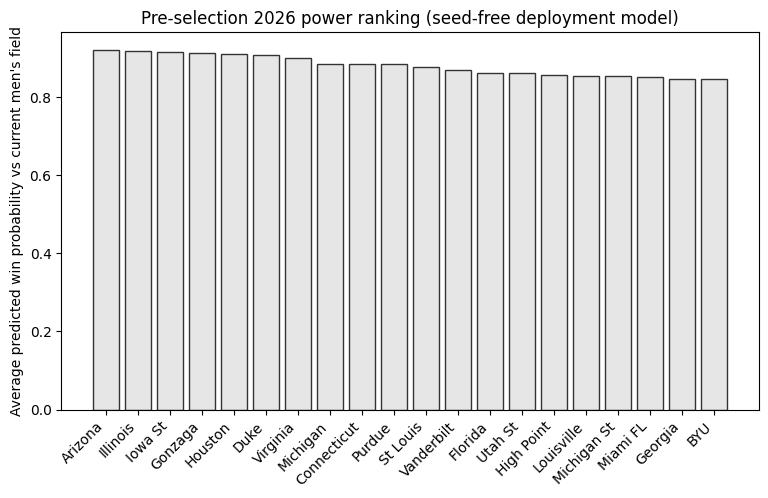

,Season,TeamID,MeanWinProbVsField,TeamName
0,2026,1112,0.920111,Arizona
1,2026,1228,0.916475,Illinois
2,2026,1235,0.914024,Iowa St
3,2026,1211,0.911960,Gonzaga
4,2026,1222,0.910738,Houston
5,2026,1181,0.906823,Duke
6,2026,1438,0.899402,Virginia
7,2026,1276,0.885580,Michigan
8,2026,1163,0.884400,Connecticut
9,2026,1345,0.883400,Purdue


In [114]:
stage2_men_named = stage2_men.merge(
    teams[["TeamID", "TeamName"]].rename(columns={"TeamID": "Team1", "TeamName": "Team1Name"}),
    on="Team1",
    how="left",
).merge(
    teams[["TeamID", "TeamName"]].rename(columns={"TeamID": "Team2", "TeamName": "Team2Name"}),
    on="Team2",
    how="left",
)

team1_side = stage2_men_named[["Season", "Team1", "Pred"]].rename(
    columns={"Team1": "TeamID", "Pred": "WinProb"}
)

team2_side = stage2_men_named[["Season", "Team2", "Pred"]].copy()
team2_side["WinProb"] = 1 - team2_side["Pred"]
team2_side = team2_side[["Season", "Team2", "WinProb"]].rename(columns={"Team2": "TeamID"})

power_rank = pd.concat([team1_side, team2_side], ignore_index=True)
power_rank = (
    power_rank.groupby(["Season", "TeamID"], as_index=False)["WinProb"]
    .mean()
    .rename(columns={"WinProb": "MeanWinProbVsField"})
    .merge(teams[["TeamID", "TeamName"]], on="TeamID", how="left")
    .sort_values("MeanWinProbVsField", ascending=False)
    .reset_index(drop=True)
)

top20_power = power_rank.head(20)

fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
ax.bar(np.arange(top20_power.shape[0]), top20_power["MeanWinProbVsField"].values, fc=".9", ec=".2")
ax.set_xticks(np.arange(top20_power.shape[0]))
ax.set_xticklabels(top20_power["TeamName"].values, rotation=45, ha="right")
ax.set_ylabel("Average predicted win probability vs current men's field")
ax.set_title(f"Pre-selection {predict_season} power ranking (seed-free deployment model)")
plt.show()

display(top20_power.head(20))

### 16.3 Current-season bracket forecast (once seeds are available)

To simulate the actual NCAA tournament, we need the 68-team seed list.  
The code below supports two cases:

1. the target season already exists in Kaggle's `MNCAATourneySeeds.csv`
2. you provide a manual/projected file at `data/men_2026_projected_seeds.csv`

Expected CSV format:

- `Season`
- `Seed`  (examples: `W01`, `X16a`, `Y11b`)
- `TeamID`

Once that file exists, the notebook will:

- refit the seed-aware model on all historical data through 2025
- build the 2026 bracket context
- plot a deterministic bracket
- estimate round-reach probabilities by simulation


In [115]:
def build_current_men_bracket_inputs(target_season, seeds_df, slots_df, projected_seed_path=None):
    if target_season in set(seeds_df["Season"].astype(int).unique()):
        current_seeds = seeds_df[seeds_df["Season"] == target_season][["Season", "Seed", "TeamID"]].copy()
    elif projected_seed_path is not None and Path(projected_seed_path).exists():
        current_seeds = pd.read_csv(projected_seed_path).copy()
    else:
        return None, None

    required = {"Season", "Seed", "TeamID"}
    missing = required - set(current_seeds.columns)
    if missing:
        raise ValueError(f"Seed file is missing required columns: {missing}")

    current_seeds["Season"] = current_seeds["Season"].astype(int)
    current_seeds["TeamID"] = current_seeds["TeamID"].astype(int)
    current_seeds["Seed"] = current_seeds["Seed"].astype(str)
    current_seeds["SeedNum"] = current_seeds["Seed"].apply(parse_seed_num)
    current_seeds["BaseSeed"] = current_seeds["Seed"].apply(base_seed)

    if target_season in set(slots_df["Season"].astype(int).unique()):
        current_slots = slots_df[slots_df["Season"] == target_season].copy()
    else:
        template_season = int(slots_df["Season"].max())
        current_slots = slots_df[slots_df["Season"] == template_season].copy()
        current_slots["Season"] = target_season

    return current_seeds, current_slots


def simulate_one_tournament_detailed(ctx, rng, deterministic=False):
    season = ctx["season"]
    model = ctx["model"]
    prob_cache = ctx["prob_cache"]
    feat_lookup = ctx["feat_lookup"]
    seed_lookup = ctx["seed_lookup"]
    seed_to_team = ctx["seed_to_team"]
    s_slots = ctx["slots"]
    feature_cols = ctx["feature_cols"]

    winners = {}
    rows = []

    def resolve(participant):
        if participant in winners:
            return winners[participant]
        if participant in seed_to_team:
            return seed_to_team[participant]
        raise KeyError(f"Could not resolve participant: {participant}")

    for _, row in s_slots.iterrows():
        slot = str(row["Slot"])
        strong = str(row["StrongSeed"])
        weak = str(row["WeakSeed"])

        team_a = resolve(strong)
        team_b = resolve(weak)

        p_a = predict_prob_team_a_wins(
            season,
            team_a,
            team_b,
            model,
            feat_lookup,
            seed_lookup,
            feature_cols,
            prob_cache=prob_cache,
        )

        winner = team_a if (p_a >= 0.5 if deterministic else rng.random() < p_a) else team_b
        winners[slot] = winner

        rows.append({
            "Season": season,
            "Slot": slot,
            "Round": int(row["Round"]),
            "StrongSeed": strong,
            "WeakSeed": weak,
            "TeamStrong": int(team_a),
            "TeamWeak": int(team_b),
            "PStrongWins": float(p_a),
            "WinnerTeamID": int(winner),
        })

    return winners, int(winners["R6CH"]), pd.DataFrame(rows)


def add_team_names_to_slot_results(slot_results, teams_df):
    out = slot_results.copy()
    name_map = teams_df[["TeamID", "TeamName"]].copy()

    out = out.merge(
        name_map.rename(columns={"TeamID": "TeamStrong", "TeamName": "TeamStrongName"}),
        on="TeamStrong",
        how="left",
    )
    out = out.merge(
        name_map.rename(columns={"TeamID": "TeamWeak", "TeamName": "TeamWeakName"}),
        on="TeamWeak",
        how="left",
    )
    out = out.merge(
        name_map.rename(columns={"TeamID": "WinnerTeamID", "TeamName": "WinnerName"}),
        on="WinnerTeamID",
        how="left",
    )
    return out


def make_bracket_plot_data(slot_results):
    main = slot_results[slot_results["Round"] >= 1].copy()
    main = main.sort_values(["Round", "Slot"]).reset_index(drop=True)

    r1_slots = list(main.loc[main["Round"] == 1, "Slot"])
    y_map = {slot: float(2 * i) for i, slot in enumerate(r1_slots)}
    x_map = {slot: 1 for slot in r1_slots}

    slot_lookup = main.set_index("Slot")[["StrongSeed", "WeakSeed"]]

    for rnd in range(2, 7):
        rnd_slots = list(main.loc[main["Round"] == rnd, "Slot"])
        for slot in rnd_slots:
            strong = slot_lookup.loc[slot, "StrongSeed"]
            weak = slot_lookup.loc[slot, "WeakSeed"]
            y_map[slot] = 0.5 * (y_map[strong] + y_map[weak])
            x_map[slot] = rnd

    plot_df = main.copy()
    plot_df["x"] = plot_df["Slot"].map(x_map)
    plot_df["y"] = plot_df["Slot"].map(y_map)
    return plot_df


def plot_deterministic_bracket(slot_results, teams_df, title=None):
    plot_df = make_bracket_plot_data(slot_results)
    plot_df = add_team_names_to_slot_results(plot_df, teams_df)

    round_labels = {
        1: "Round of 64",
        2: "Round of 32",
        3: "Sweet 16",
        4: "Elite 8",
        5: "Final Four",
        6: "Title",
    }

    fig, ax = plt.subplots(figsize=(16, 10), dpi=120)

    slot_to_xy = plot_df.set_index("Slot")[["x", "y"]].to_dict("index")
    for _, row in plot_df.iterrows():
        if row["Round"] == 1:
            continue
        x = row["x"]
        strong = row["StrongSeed"]
        weak = row["WeakSeed"]
        y1 = slot_to_xy[strong]["y"]
        y2 = slot_to_xy[weak]["y"]

        ax.plot([x - 1 + 0.15, x - 0.15], [y1, y1], color=".5", lw=1.2)
        ax.plot([x - 1 + 0.15, x - 0.15], [y2, y2], color=".5", lw=1.2)
        ax.plot([x - 0.15, x - 0.15], [y1, y2], color=".5", lw=1.2)

    for _, row in plot_df.iterrows():
        x = row["x"]
        y = row["y"]
        if row["Round"] == 1:
            label = f"{row['TeamStrongName']} vs {row['TeamWeakName']}\nP(strong wins)={row['PStrongWins']:.2f}"
        else:
            label = f"{row['WinnerName']}\n(slot {row['Slot']})"

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=".5"),
        )

    y_top = plot_df["y"].max() + 2
    for rnd, label in round_labels.items():
        ax.text(rnd, y_top, label, ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(-2, y_top + 2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    if title is not None:
        ax.set_title(title, fontsize=14)

    plt.show()


def round_reach_probabilities(ctx, teams_df, n_sims=300, rng_seed=5442):
    rng = np.random.default_rng(rng_seed)

    team_ids = sorted(set(int(v) for v in ctx["seed_to_team"].values()))
    counts = {
        tid: {
            "Round of 32": 0,
            "Sweet 16": 0,
            "Elite 8": 0,
            "Final Four": 0,
            "Title Game": 0,
            "Champion": 0,
        }
        for tid in team_ids
    }

    for _ in range(n_sims):
        _, _, detail = simulate_one_tournament_detailed(ctx, rng, deterministic=False)

        for _, row in detail.iterrows():
            winner = int(row["WinnerTeamID"])
            rnd = int(row["Round"])

            if rnd == 1:
                counts[winner]["Round of 32"] += 1
            elif rnd == 2:
                counts[winner]["Sweet 16"] += 1
            elif rnd == 3:
                counts[winner]["Elite 8"] += 1
            elif rnd == 4:
                counts[winner]["Final Four"] += 1
            elif rnd == 5:
                counts[winner]["Title Game"] += 1
            elif rnd == 6:
                counts[winner]["Champion"] += 1

    out = pd.DataFrame.from_dict(counts, orient="index").rename_axis("TeamID").reset_index()
    for c in ["Round of 32", "Sweet 16", "Elite 8", "Final Four", "Title Game", "Champion"]:
        out[c] = out[c] / n_sims

    out = out.merge(teams_df[["TeamID", "TeamName"]], on="TeamID", how="left")
    return out.sort_values("Champion", ascending=False).reset_index(drop=True)

In [116]:
projected_men_seeds_path = Path("data/men_2026_projected_seeds.csv")

current_seeds, current_slots = build_current_men_bracket_inputs(
    predict_season,
    seeds,
    slots,
    projected_seed_path=projected_men_seeds_path,
)

if current_seeds is None:
    print("No official/projected men's 2026 seeds found yet.")
    print("To enable the bracket cells, add data/men_2026_projected_seeds.csv")
    print("with columns: Season, Seed, TeamID")
else:
    seeds_for_bracket = pd.concat(
        [seeds[seeds["Season"] != predict_season], current_seeds],
        ignore_index=True,
    )
    slots_for_bracket = pd.concat(
        [slots[slots["Season"] != predict_season], current_slots],
        ignore_index=True,
    )

    ctx_current = prepare_tournament_context(
        predict_season,
        seed_bracket_model,
        seeds_for_bracket,
        slots_for_bracket,
        team_season,
        feature_cols,
    )

    rng = np.random.default_rng(5442)
    _, champion_current, slot_results_current = simulate_one_tournament_detailed(
        ctx_current, rng, deterministic=True
    )

    champion_name = teams.loc[teams["TeamID"] == champion_current, "TeamName"].iloc[0]
    print("Deterministic bracket champion:", champion_name)

    plot_deterministic_bracket(
        slot_results_current,
        teams,
        title=f"Deterministic {predict_season} men's bracket (seed-aware model)",
    )

    reach_current = round_reach_probabilities(
        ctx_current,
        teams,
        n_sims=N_TOURNEY_SIMS,
        rng_seed=5442,
    )

    slot_results_current_named = add_team_names_to_slot_results(slot_results_current, teams)
    slot_results_current_named.to_csv(
        f"men_{predict_season}_deterministic_bracket_slots.csv", index=False
    )
    reach_current.to_csv(f"men_{predict_season}_round_reach_probs.csv", index=False)

    display(reach_current.head(15))

No official/projected men's 2026 seeds found yet.
To enable the bracket cells, add data/men_2026_projected_seeds.csv
with columns: Season, Seed, TeamID


---

## 17. Limitations and what would make this better

This notebook intentionally stays on the "teachable" side of March Madness modeling. A few important limitations (and how sports analytics teams usually address them):

1. **No opponent adjustment**  
   A team can rack up strong raw efficiency in a weak conference.  
   Common fix: opponent-adjusted ratings (SRS, KenPom-style adjustments, Elo, Massey systems).

2. **No player-level information**  
   Injuries, rotations, and lineup changes matter a lot in March.  
   Common fix: incorporate player minutes, injuries, and lineup-based features.

3. **Temporal dynamics are ignored**  
   We summarized an entire season into one vector.  
   Common fix: emphasize late-season games, include trend features, or use game-level sequences.

4. **Single model, single feature set**  
   In practice, ensembles often perform better: blending seeds, efficiency, Elo, and rating systems.

None of these fixes are magical — they are ways of making the feature representation closer to the real causal story of "who wins games."


---

## 17. Literature review: how people predict March Madness (and what to learn from it)

There is no single "correct" way to model the NCAA tournament. But there *are* recurring ideas that show up across research papers, Kaggle solutions, and industry-style forecasting systems.

A useful way to organize the space is by asking: **what is the model trying to estimate?**

### 17.1 Game-level win probabilities as the core object

Most modern approaches reduce bracket prediction to a simpler primitive:

> Estimate $P(\text{Team A beats Team B})$ for any matchup, then use the bracket structure to turn those probabilities into a simulated tournament.

This is exactly what we did in Sections 7–14.

You will see this pattern in many places:

- **Paired-comparison / rating-difference models** (often a logistic or probit link):  
  you assume that "team strength" exists on a latent scale, and the win probability depends on a difference in strengths.  
  (Appendix D connects this idea to Elo- and Bradley–Terry–style ratings.)
- **Efficiency- and feature-based machine learning models:**  
  you construct features for Team A and Team B (or differences like $\Delta\text{NetEff}$) and learn a mapping to a win probability.
- **Ensembles:**  
  you average or blend multiple probability models to reduce variance and exploit complementary signal.

Kvam & Sokol's LRMC approach (logistic regression + Markov chain) is a classic example of "probabilities first, bracket second."  
West (2006) gives an example of a flexible rating-style framework aimed at tournament prediction.  
Yuan et al. (2015) is a useful example of combining multiple models ("mixture of modelers") and taking evaluation design seriously.

### 17.2 What features matter in practice?

The predictive signal in college basketball is limited, especially once you condition on "tournament teams." That is part of why brackets feel so random.

Empirically, strong feature families tend to include:

- **Seeding / committee information** (seeds summarize a lot of latent strength)
- **Tempo-free efficiencies** (offensive and defensive efficiency per possession)
- **Opponent-adjusted ratings** (strength-of-schedule corrections matter)
- **Betting markets** (closing lines often embed information that is hard to capture elsewhere)

In other words: many methods differ mainly in **how they estimate "team strength"** and how carefully they avoid leakage.

### 17.3 The Kaggle framing (and why it matters)

Kaggle's "March Machine Learning Mania" competitions popularized a very specific formulation:

- You submit predicted probabilities for *many potential matchups* (not just the games that end up being played).
- Your score is computed using a proper scoring rule (log loss) on the games that actually occur.

This matters because:

- It encourages **well-calibrated probabilities**, not just "winner picks."
- It makes bracket simulation natural: if you have $P(\text{A beats B})$ for arbitrary pairs, you can simulate the full tournament.

### 17.4 What this notebook is (and is not)

This notebook is intentionally a first serious step:

- We build interpretable and reproducible features from box scores.
- We use season-aware splitting to mimic forecasting.
- We compare logistic regression to random forests and emphasize probability scoring and calibration.
- We simulate brackets rather than pretending that single-game accuracy is the whole story.

What this notebook is *not* yet doing:

- Opponent-adjusted efficiencies (we use unadjusted season totals).
- Player-level information (injuries, roster turnover, minutes distributions).
- Market-based information (Vegas lines, implied probabilities).
- Model ensembles beyond a single random forest.

Those are all reasonable next steps — but the core workflow (features → probabilities → evaluation → simulation) stays the same.


---

## 18. Open-source and competition examples worth reading

The Kaggle March Madness competitions have produced a large ecosystem of public baselines and writeups. Reading a few end-to-end pipelines is a fast way to learn practical habits (and common mistakes).

A few starting points (these are not the only good ones):

- **Kaggle "March Machine Learning Mania" competition pages** (data dictionaries, evaluation metric, submission format).  
  Search for "March Machine Learning Mania" on Kaggle and look at the "Data" tab.

- **FiveThirtyEight's March Madness forecasts**  
  A well-known public example of probabilistic forecasting for the tournament (useful for understanding how ratings + uncertainty + simulation fit together).

- **sfirke/predicting-march-madness (GitHub)**  
  A tutorial-style repository aimed at building a Kaggle entry (includes an end-to-end workflow).

- **paul-lindquist/machine-learning-vs-march-madness (GitHub)**  
  A project writeup comparing several classifiers (including random forests) using Kaggle March Madness data.

When you read public solutions, keep two questions in mind:

1. **What is the unit of prediction?**  
   - predicting game outcomes, round advancement, or bracket score are different problems.
2. **What is the evaluation design?**  
   - random split, season split, and "pseudo-real-time" are not interchangeable.

A strong habit is to replicate a public baseline exactly, then change *one thing at a time* and measure the effect under the same evaluation design.


---

## 19. Possible real datasets to try next (for projects)

If you want to go beyond this notebook, here are realistic next datasets and feature directions:

1. **Opponent-adjusted team ratings**  
   Public systems include Bart Torvik (T-Rank), Massey ratings, and other ordinal/ranking systems.  
   The Kaggle dataset also includes `MMasseyOrdinals.csv`.

2. **Betting markets (closing lines, implied probabilities)**  
   Markets can be strong baselines and a useful comparator for calibration.

3. **Play-by-play data**  
   With event-level sequences, you can build lineup-based or style-based features (pace under pressure, foul rates, clutch efficiency).

4. **Player-level and injury data**  
   Even coarse proxies (minutes concentration, star availability indicators) often help.

A good project strategy is to add *one* new data source and measure whether it improves out-of-season evaluation (e.g., predicting 2025 using data through 2024).


---

# Appendices

These sections go a bit deeper mathematically or implementationally. They are not required to use the modeling workflow above.


## Appendix A. Where log loss comes from (Bernoulli likelihood)

Assume each label $y_i \in \{0,1\}$ is Bernoulli with success probability $p_i$.

The Bernoulli probability mass function is:

$$
P(y_i \mid p_i) = p_i^{y_i}(1-p_i)^{1-y_i}
$$

For independent examples, the likelihood is:

$$
\mathcal{L} = \prod_{i=1}^n p_i^{y_i}(1-p_i)^{1-y_i}
$$

Taking logs:

$$
\log \mathcal{L} = \sum_{i=1}^n \left( y_i\log(p_i) + (1-y_i)\log(1-p_i) \right)
$$

Maximizing $\log \mathcal{L}$ is equivalent to minimizing the negative average log-likelihood:

$$
-\frac{1}{n}\log \mathcal{L} = -\frac{1}{n}\sum_{i=1}^n \left( y_i\log(p_i) + (1-y_i)\log(1-p_i) \right)
$$

That is exactly **log loss**.


In [117]:
# Tiny confirmation: negative average log-likelihood equals log loss
y_ex = np.array([1, 0, 1, 1])
p_ex = np.array([0.8, 0.3, 0.6, 0.9])

lik = np.prod((p_ex ** y_ex) * ((1 - p_ex) ** (1 - y_ex)))
loglik = np.log(lik)
neg_avg_loglik = -loglik / len(y_ex)

print("Negative average log-likelihood:", neg_avg_loglik)
print("sklearn log_loss:", log_loss(y_ex, p_ex))


Negative average log-likelihood: 0.2990011586691898
sklearn log_loss: 0.2990011586691898


## Appendix B. Logistic regression as maximum likelihood (and the role of regularization)

Logistic regression models probabilities as:

$$
p_i = \sigma(z_i), \quad z_i = \beta_0 + x_i^\top\beta
$$

With L2 regularization (ridge), we minimize:

$$
\text{Objective} = \text{LogLoss} + \lambda \sum_{j=1}^p \beta_j^2
$$

In scikit-learn:

- `penalty="l2"` and `C = 1/\lambda`.


## Appendix C. Optional: logistic regression from scratch (gradient descent on the toy data)

This appendix is for students who want to see what `fit` is doing under the hood.

We minimize average log loss for the toy dataset:

$$
J(\beta_0, \beta_1) = -\frac{1}{n}\sum_{i=1}^n \left( y_i\log(p_i) + (1-y_i)\log(1-p_i) \right)
$$

where $p_i = \sigma(\beta_0 + \beta_1 x_i)$.

A useful gradient identity:

$$
\frac{\partial J}{\partial \beta_0} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i),
\quad
\frac{\partial J}{\partial \beta_1} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i) x_i
$$

The code below runs only if `RUN_OPTIONAL=True`.


In [118]:
def fit_logreg_gd(x, y, lr=0.8, n_steps=1500):
    """Fit 1D logistic regression with plain gradient descent (educational).

    This appendix is not needed to *use* logistic regression in practice,
    but it is useful for understanding what "fitting a model" means.

    Model:
        $$p_i = \sigma(\beta_0 + \beta_1 x_i)$$

    Objective (binary log loss / cross-entropy):
        $$J(\beta_0, \beta_1) = -\frac{1}{n}\sum_{i=1}^n \left[y_i\log(p_i) + (1-y_i)\log(1-p_i)\right].$$

    Gradients (you can derive these by chain rule):
        $$\frac{\partial J}{\partial \beta_0} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i),$$
        $$\frac{\partial J}{\partial \beta_1} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i)x_i.$$

    Parameters
    ----------
    x : array-like, shape (n,)
        Single feature values.
    y : array-like, shape (n,)
        Binary labels in {0, 1}.
    lr : float
        Learning rate (step size).
    n_steps : int
        Number of gradient steps.

    Returns
    -------
    beta0, beta1 : float
        Fitted parameters.
    hist : pandas.DataFrame
        Small training history (objective value every 100 steps).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    assert x.ndim == 1
    assert y.ndim == 1
    assert x.shape[0] == y.shape[0]

    beta0 = 0.0
    beta1 = 0.0

    hist = []
    for step in range(n_steps):
        # Forward pass: predicted probabilities
        p = sigmoid(beta0 + beta1 * x)

        # Objective value (mean log loss)
        J = log_loss_manual(y, p)

        # Gradients (mean over examples)
        grad0 = np.mean(p - y)
        grad1 = np.mean((p - y) * x)

        # Gradient descent update
        beta0 -= lr * grad0
        beta1 -= lr * grad1

        # Save a small history so we can plot convergence
        if step % 100 == 0 or step == n_steps - 1:
            hist.append({"step": step, "J": J, "beta0": beta0, "beta1": beta1})

    return beta0, beta1, pd.DataFrame(hist)

,step,J,beta0,beta1
11,1100,0.539864,-0.147473,1.369847
12,1200,0.539864,-0.147473,1.369847
13,1300,0.539864,-0.147473,1.369847
14,1400,0.539864,-0.147473,1.369847
15,1499,0.539864,-0.147473,1.369847


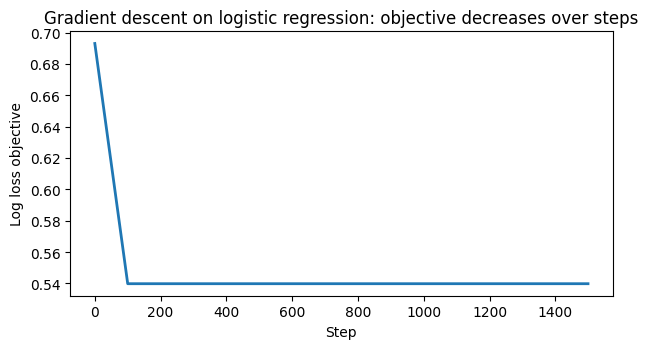

In [119]:
beta0_gd, beta1_gd, hist = fit_logreg_gd(toy["x"].values, toy["y"].values)
display(hist.tail())

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=100)
ax.plot(hist["step"], hist["J"], linewidth=2)

ax.set_xlabel("Step")
ax.set_ylabel("Log loss objective")
ax.set_title("Gradient descent on logistic regression: objective decreases over steps")

plt.show()

## Appendix D. Optional: adding rating systems (Massey ordinals)

The Kaggle dataset includes `MMasseyOrdinals.csv`, which contains many team rating/ranking systems over time.

A simple way to use this:

1. Pick a system (or average across systems).
2. For each season and team, take the **latest** available ordinal rank before the tournament.
3. Add rank differences as additional features.

This can help because it partially addresses opponent strength.

The code below runs only if `RUN_OPTIONAL=True`.


In [120]:
massey = pd.read_csv(extract_dir + "MMasseyOrdinals.csv")

recent = massey[massey["Season"] >= 2015]
SYSTEM = recent["SystemName"].value_counts().index[0]
print("Using system:", SYSTEM)

massey_latest = (
    massey[massey["SystemName"] == SYSTEM]
    .sort_values("RankingDayNum")
    .groupby(["Season", "TeamID"], as_index=False)
    .tail(1)
    .rename(columns={"OrdinalRank": "MasseyRank"})[["Season", "TeamID", "MasseyRank"]]
)

team_season_aug = team_season.merge(massey_latest, on=["Season", "TeamID"], how="left")
print("Augmented team_season rows with rank available:", team_season_aug["MasseyRank"].notna().sum())

Using system: MAS
Augmented team_season rows with rank available: 6987


---

## Appendix E. Optional: Cross-validation by season (and what GroupKFold is doing)

In the main notebook we used **grouped cross-validation by season** to tune hyperparameters.

This appendix makes that idea explicit.

### E.1 A generic definition of $K$-fold cross-validation

Suppose we have $n$ supervised learning examples $(x_i, y_i)$ for $i=1,\dots,n$.

- $x_i$ is the feature vector for example $i$
- $y_i$ is the observed outcome for example $i$
- $\ell(y, \hat{p})$ is a loss function that measures how good a predicted probability $\hat{p}$ is when the outcome is $y$  
  (in this notebook, $\ell$ is usually **log loss** or **Brier loss**)

In $K$-fold cross-validation, we split the indices $\{1,\dots,n\}$ into $K$ disjoint folds:
$I_1,\dots,I_K$.

For each fold $k$:

- Fit the model on all examples *not* in the fold: $\{1,\dots,n\}\setminus I_k$
- Predict on the held-out fold $I_k$

A common cross-validation estimate of risk is:

$$
\widehat{R}_{CV}
=
\frac{1}{K}
\sum_{k=1}^K
\left(
\frac{1}{|I_k|}
\sum_{i\in I_k}
\ell\left(y_i,\hat{p}^{(-k)}(x_i)\right)
\right),
$$

where:

- $K$ is the number of folds
- $I_k$ is the set of held-out indices in fold $k$
- $|I_k|$ is the size of fold $k$
- $\hat{p}^{(-k)}(\cdot)$ is the probability model fit **without** fold $k$

Intuition: each example plays the role of "test data" exactly once, and we average the resulting losses.

### E.2 Why we group by season

If we are trying to forecast future tournaments, a random $K$-fold split mixes seasons and can implicitly "train on the future."

A **grouped** split (GroupKFold) forces each fold to be made of whole seasons:

- Training fold: some set of seasons
- Validation fold: different seasons

That better matches the real forecasting task.


In [121]:
# Micro-example: KFold vs GroupKFold, and a direct computation of the CV estimate
from sklearn.model_selection import KFold, GroupKFold
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(5442)

# A toy dataset: 3 "seasons" (groups), with 10 observations each
seasons_toy = np.repeat([2022, 2023, 2024], repeats=10)
n_obs = len(seasons_toy)

# One toy feature and a synthetic outcome
x_toy = rng.normal(size=n_obs)
p_toy = sigmoid(0.8 * x_toy)
y_toy_cv = rng.binomial(1, p_toy, size=n_obs)

X_toy_cv = pd.DataFrame({"x": x_toy})

In [122]:
def cv_log_loss(splitter, X_df, y_arr, groups=None):
    """Compute an average CV log loss by explicitly implementing the definition.

    This maps directly to the equation in the appendix:

    - K          -> splitter.n_splits
    - I_k        -> test_idx in the loop
    - |I_k|      -> len(test_idx)
    - \ell(...)  -> per-fold log loss on test_idx
    """
    fold_losses = []
    for fold, (train_idx, test_idx) in enumerate(splitter.split(X_df, y_arr, groups=groups), start=1):
        model = LogisticRegression(max_iter=2000).fit(X_df.iloc[train_idx], y_arr[train_idx])
        p_hat = model.predict_proba(X_df.iloc[test_idx])[:, 1]
        fold_loss = log_loss(y_arr[test_idx], p_hat)  # average loss on fold k
        fold_losses.append(fold_loss)

    return float(np.mean(fold_losses)), fold_losses

In [123]:
# Random KFold (mixes seasons)
kf = KFold(n_splits=3, shuffle=True, random_state=5442)
kf_mean, kf_folds = cv_log_loss(kf, X_toy_cv, y_toy_cv)

# GroupKFold (holds out whole seasons)
gkf = GroupKFold(n_splits=3)
gkf_mean, gkf_folds = cv_log_loss(gkf, X_toy_cv, y_toy_cv, groups=seasons_toy)

print("KFold fold losses:     ", np.round(kf_folds, 4), "  mean:", round(kf_mean, 4))
print("GroupKFold fold losses:", np.round(gkf_folds, 4), "  mean:", round(gkf_mean, 4))

# Show the season composition of each GroupKFold validation fold
for fold, (_, test_idx) in enumerate(gkf.split(X_toy_cv, y_toy_cv, groups=seasons_toy), start=1):
    print(f"GroupKFold fold {fold} validation seasons:", np.unique(seasons_toy[test_idx]))

KFold fold losses:      [0.6942 0.763  0.9317]   mean: 0.7963
GroupKFold fold losses: [0.6883 0.9395 0.7598]   mean: 0.7959
GroupKFold fold 1 validation seasons: [2024]
GroupKFold fold 2 validation seasons: [2023]
GroupKFold fold 3 validation seasons: [2022]


---

## Appendix F. Optional: Bagging and OOB estimation from scratch (toy example)

This appendix is for when you want to "look under the hood" of a random forest.

A random forest combines two ideas:

1. **Bagging** (bootstrap aggregating): train many trees on bootstrap samples.
2. **Random feature selection**: when splitting a node, consider only a random subset of features.

Here we implement *bagging only* on a toy dataset to make the mechanics concrete.

We will:

- draw bootstrap samples
- fit many decision trees
- average their predicted probabilities
- compute an **out-of-bag (OOB)** estimate of log loss

This is conceptually what `RandomForestClassifier(oob_score=True)` is doing internally, but in a simplified setting.


In [124]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

rng = np.random.default_rng(5442)

# Toy nonlinear classification problem
X_moons, y_moons = make_moons(n_samples=900, noise=0.25, random_state=5442)
X_moons = pd.DataFrame(X_moons, columns=["x1", "x2"])
y_moons = y_moons.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_moons, y_moons, test_size=0.30, random_state=5442, stratify=y_moons
)

n_train = X_tr.shape[0]
B = 80  # number of bootstrap trees (keep modest for speed)

# Storage for OOB probability estimates on the TRAIN set
oob_sum = np.zeros(n_train)
oob_count = np.zeros(n_train)


In [125]:
trees = []

for b in range(B):
    # Bootstrap sample of indices (with replacement)
    boot_idx = rng.integers(0, n_train, size=n_train)

    # OOB indices: those never selected in boot_idx
    in_bag = np.zeros(n_train, dtype=bool)
    in_bag[boot_idx] = True
    oob_idx = np.where(~in_bag)[0]

    # Fit a tree on the bootstrap sample
    tree = DecisionTreeClassifier(
        random_state=b,
        min_samples_leaf=5,   # smoothing to make probabilities less extreme
    )
    tree.fit(X_tr.iloc[boot_idx], y_tr[boot_idx])
    trees.append(tree)

    # Predict only on OOB rows for this tree (to avoid leakage)
    if len(oob_idx) > 0:
        p_oob = tree.predict_proba(X_tr.iloc[oob_idx])[:, 1]
        oob_sum[oob_idx] += p_oob
        oob_count[oob_idx] += 1


In [126]:
# Aggregate OOB predictions where available
has_oob = oob_count > 0
p_oob_avg = np.empty(n_train)
p_oob_avg[:] = np.nan
p_oob_avg[has_oob] = oob_sum[has_oob] / oob_count[has_oob]

oob_logloss = log_loss(y_tr[has_oob], p_oob_avg[has_oob])

# Bagged prediction on the TEST set
p_test = np.mean([t.predict_proba(X_te)[:, 1] for t in trees], axis=0)
test_logloss = log_loss(y_te, p_test)

print("Bagging demo (toy moons dataset)")
print("  OOB log loss (train OOB only):", round(oob_logloss, 4))
print("  Test log loss:                ", round(test_logloss, 4))

# Basic sanity checks
assert np.isfinite(oob_logloss)
assert np.isfinite(test_logloss)


Bagging demo (toy moons dataset)
  OOB log loss (train OOB only): 0.3538
  Test log loss:                 0.295


---

## Appendix G. Optional: Creating a Kaggle-style submission file (one season)

Kaggle's March Madness competitions typically ask you to submit a CSV with rows like:

- `ID = "2025_1101_1102"`
- `Pred = P(Team1 beats Team2)`

where:

- the `ID` encodes the season and the two TeamIDs
- Team1 and Team2 are usually listed in increasing order (Team1 < Team2)

This appendix shows how to generate predictions for a given season **in a vectorized way**:

- parse IDs into `(Season, Team1, Team2)`
- merge in team-season features and seeds
- compute difference features (Team1 − Team2)
- call `best_model.predict_proba(...)`

Caveats and practical notes:

- The Kaggle sample submissions often include **both men's and women's** matchups.
  In this notebook we train a men's model, so we demonstrate the workflow on men's matchups only.
- Seeds are only available for **tournament teams**.
  For many rows in the Kaggle submission (non-tournament teams), `SeedNum` is missing.
  In this demo we drop rows with missing seeds and fill them with `0.5` as a placeholder.
  A full competition entry would either (i) build seed-free features for all teams, (ii) impute seeds, or (iii) submit a separate model for non-seeded teams.

(Extending to women is conceptually identical: repeat the feature engineering and training steps using the women's tables.)


In [127]:
# Load the combined sample submission (men + women)
sample_sub = pd.read_csv(extract_dir + "SampleSubmissionStage1.csv")

# Focus on one season for a manageable demo
target_season = 2025
sub_season = sample_sub[sample_sub["ID"].str.startswith(f"{target_season}_")].copy()

# Parse ID -> Season, Team1, Team2
parts = sub_season["ID"].str.split("_", expand=True)
sub_season["Season"] = parts[0].astype(int)
sub_season["Team1"] = parts[1].astype(int)
sub_season["Team2"] = parts[2].astype(int)


In [128]:
# Identify men's TeamIDs from MTeams.csv
men_team_ids = set(teams["TeamID"].astype(int).unique())

is_men = sub_season["Team1"].isin(men_team_ids) & sub_season["Team2"].isin(men_team_ids)
sub_men = sub_season[is_men].copy()

print("Rows in sample submission for season", target_season, ":", sub_season.shape[0])
print("Men's-only subset rows:", sub_men.shape[0])

Rows in sample submission for season 2025 : 131407
Men's-only subset rows: 66066


In [129]:
# Build a vectorized feature matrix for all matchups in sub_men
# (Team1 and Team2 here already satisfy Team1 < Team2 in the sample submission)
# feature_cols is already defined in the main notebook

feats = team_season[["Season", "TeamID"] + feature_cols].copy()
seeds_small = seeds[["Season", "TeamID", "SeedNum"]].drop_duplicates().copy()

sub_men = sub_men.merge(seeds_small.rename(columns={"TeamID": "Team1", "SeedNum": "SeedNum1"}),
                        on=["Season", "Team1"], how="left")
sub_men = sub_men.merge(seeds_small.rename(columns={"TeamID": "Team2", "SeedNum": "SeedNum2"}),
                        on=["Season", "Team2"], how="left")
sub_men["SeedDiff"] = sub_men["SeedNum1"] - sub_men["SeedNum2"]

sub_men = sub_men.merge(
    feats.rename(columns={c: f"{c}_1" for c in feature_cols}).rename(columns={"TeamID": "Team1"}),
    on=["Season", "Team1"], how="left"
)
sub_men = sub_men.merge(
    feats.rename(columns={c: f"{c}_2" for c in feature_cols}).rename(columns={"TeamID": "Team2"}),
    on=["Season", "Team2"], how="left"
)

for c in feature_cols:
    sub_men[f"d_{c}"] = sub_men[f"{c}_1"] - sub_men[f"{c}_2"]

model_cols = [f"d_{c}" for c in feature_cols] + ["SeedDiff"]

In [130]:
model_cols

['d_WinPct',
 'd_MarginPG',
 'd_Tempo',
 'd_OffEff',
 'd_DefEff',
 'd_NetEff',
 'd_eFG',
 'd_TOV_rate',
 'd_FTR',
 'd_ORB_rate',
 'SeedDiff']

In [131]:
sub_men

,ID,Pred,Season,Team1,Team2,SeedNum1,SeedNum2,SeedDiff,WinPct_1,MarginPG_1,Tempo_1,OffEff_1,DefEff_1,NetEff_1,eFG_1,TOV_rate_1,FTR_1,ORB_rate_1,WinPct_2,MarginPG_2,Tempo_2,OffEff_2,DefEff_2,NetEff_2,eFG_2,TOV_rate_2,FTR_2,ORB_rate_2,d_WinPct,d_MarginPG,d_Tempo,d_OffEff,d_DefEff,d_NetEff,d_eFG,d_TOV_rate,d_FTR,d_ORB_rate
0,2025_1101_1102,0.5,2025,1101,1102,NaN,NaN,NaN,0.448276,-3.448276,71.718966,94.189485,98.997524,-4.808039,0.466891,0.198091,0.371551,0.277042,0.125000,-11.718750,65.240625,94.937012,112.899363,-17.962351,0.500928,0.186808,0.353960,0.198953,0.323276,8.270474,6.478341,-0.747527,-13.901839,13.154312,-0.034037,0.011283,0.017591,0.078089
1,2025_1101_1103,0.5,2025,1101,1103,NaN,13.0,NaN,0.448276,-3.448276,71.718966,94.189485,98.997524,-4.808039,0.466891,0.198091,0.371551,0.277042,0.812500,8.062500,74.070312,113.363569,102.478641,10.884928,0.554337,0.158633,0.268031,0.315529,-0.364224,-11.510776,-2.351347,-19.174084,-3.481118,-15.692967,-0.087446,0.039458,0.103520,-0.038487
2,2025_1101_1104,0.5,2025,1101,1104,NaN,2.0,NaN,0.448276,-3.448276,71.718966,94.189485,98.997524,-4.808039,0.466891,0.198091,0.371551,0.277042,0.757576,9.696970,77.853788,117.041463,104.586103,12.455360,0.563500,0.155692,0.401223,0.327010,-0.309300,-13.145246,-6.134822,-22.851978,-5.588579,-17.263399,-0.096608,0.042399,-0.029672,-0.049968
3,2025_1101_1105,0.5,2025,1101,1105,NaN,NaN,NaN,0.448276,-3.448276,71.718966,94.189485,98.997524,-4.808039,0.466891,0.198091,0.371551,0.277042,0.241379,-10.586207,74.509483,93.022180,107.230045,-14.207865,0.450980,0.202705,0.385813,0.318490,0.206897,7.137931,-2.790517,1.167305,-8.232521,9.399826,0.015911,-0.004614,-0.014262,-0.041448
4,2025_1101_1106,0.5,2025,1101,1106,NaN,16.0,NaN,0.448276,-3.448276,71.718966,94.189485,98.997524,-4.808039,0.466891,0.198091,0.371551,0.277042,0.545455,-0.303030,71.091667,101.533445,101.959698,-0.426253,0.470560,0.122761,0.298745,0.258173,-0.097179,-3.145246,0.627299,-7.343960,-2.962174,-4.381786,-0.003668,0.075330,0.072806,0.018869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,2025_1477_1479,0.5,2025,1477,1479,NaN,NaN,NaN,0.161290,-10.516129,69.322581,92.833876,108.003723,-15.169846,0.491832,0.210796,0.280047,0.252567,0.428571,-5.964286,65.262500,100.801707,109.940624,-9.138917,0.486397,0.149397,0.309224,0.208134,-0.267281,-4.551843,4.060081,-7.967831,-1.936902,-6.030929,0.005435,0.061399,-0.029177,0.044433
66062,2025_1477_1480,0.5,2025,1477,1480,NaN,NaN,NaN,0.161290,-10.516129,69.322581,92.833876,108.003723,-15.169846,0.491832,0.210796,0.280047,0.252567,0.166667,-11.066667,69.789167,97.101986,112.959270,-15.857284,0.471894,0.150931,0.288364,0.245245,-0.005376,0.550538,-0.466586,-4.268110,-4.955548,0.687438,0.019938,0.059865,-0.008318,0.007321
66063,2025_1478_1479,0.5,2025,1478,1479,NaN,NaN,NaN,0.233333,-9.466667,70.778333,101.631855,115.006947,-13.375091,0.515343,0.182730,0.376655,0.244009,0.428571,-5.964286,65.262500,100.801707,109.940624,-9.138917,0.486397,0.149397,0.309224,0.208134,-0.195238,-3.502381,5.515833,0.830148,5.066322,-4.236174,0.028946,0.033333,0.067431,0.035875
66064,2025_1478_1480,0.5,2025,1478,1480,NaN,NaN,NaN,0.233333,-9.466667,70.778333,101.631855,115.006947,-13.375091,0.515343,0.182730,0.376655,0.244009,0.166667,-11.066667,69.789167,97.101986,112.959270,-15.857284,0.471894,0.150931,0.288364,0.245245,0.066667,1.600000,0.989167,4.529870,2.047676,2.482193,0.043449,0.031799,0.088290,-0.001237


In [132]:
# Drop rows that we cannot feature-engineer (should be rare if data is complete)
before = sub_men.shape[0]
sub_men = sub_men.dropna(subset=model_cols).copy()
after = sub_men.shape[0]
print("Dropped rows with missing features:", before - after)

X_submit = sub_men[model_cols]
sub_men["Pred"] = final_model.predict_proba(X_submit)[:, 1]

Dropped rows with missing features: 63788


In [133]:
# Create a demonstration submission file:
# - Use men's predictions where available
# - Fill remaining rows with 0.5 (uninformative) as a placeholder
submission = sample_sub[sample_sub["ID"].str.startswith(f"{target_season}_")].copy()
submission["Pred"] = 0.5

submission = submission.merge(sub_men[["ID", "Pred"]], on="ID", how="left", suffixes=("", "_men"))
submission["Pred"] = np.where(submission["Pred_men"].notna(), submission["Pred_men"], submission["Pred"])
submission = submission[["ID", "Pred"]]

# out_path = f"submission_demo_{target_season}.csv"
# submission.to_csv(out_path, index=False)

# print("Wrote:", out_path)
display(submission.head())


,ID,Pred
0,2025_1101_1102,0.5
1,2025_1101_1103,0.5
2,2025_1101_1104,0.5
3,2025_1101_1105,0.5
4,2025_1101_1106,0.5


## Appendix G. Why did `dropna` remove so many rows in the sample-submission demo?

This is a subtle but important point.

`SampleSubmissionStage1.csv` contains **all possible team pairs**, not just actual tournament teams.  
For the men's 2025 rows, that means:

- 364 men's teams in the file  →  $\binom{364}{2} = 66{,}066$ men's matchup rows
- only 68 seeded tournament teams
- only $\binom{68}{2} = 2{,}278$ men's rows where both teams have official NCAA seeds

So the huge row drop at the end was *not* a broken feature merge.  
It happened because `SeedDiff` is only defined when **both teams are seeded**.

A cleaner pattern is:

1. explicitly filter to seeded tournament teams first
2. then merge features
3. use `dropna` only as a final sanity check

---

## References

This notebook draws on a mix of (i) core machine learning references, (ii) probability/evaluation references, and (iii) sports analytics / March Madness–specific work.

**Core ML / statistical learning (broad background)**
- Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani. *An Introduction to Statistical Learning* (2nd ed.). Springer, 2021.
- Trevor Hastie, Robert Tibshirani, Jerome Friedman. *The Elements of Statistical Learning* (2nd ed.). Springer, 2009.
- Kevin P. Murphy. *Machine Learning: A Probabilistic Perspective*. MIT Press, 2012.
- Christopher M. Bishop. *Pattern Recognition and Machine Learning*. Springer, 2006.
- Shai Shalev-Shwartz, Shai Ben-David. *Understanding Machine Learning: From Theory to Algorithms*. Cambridge University Press, 2014.

**Resampling, model selection, and evaluation**
- Sylvain Arlot, Alain Celisse. "A survey of cross-validation procedures for model selection." *Statistics Surveys* 4, 40–79, 2010.
- Bradley Efron, Robert Tibshirani. *An Introduction to the Bootstrap*. Chapman & Hall/CRC, 1993.
- Glenn W. Brier. "Verification of forecasts expressed in terms of probability." *Monthly Weather Review* 78(1), 1–3, 1950. (Brier score)
- Alexandru Niculescu-Mizil, Rich Caruana. "Predicting Good Probabilities with Supervised Learning." *Proceedings of ICML*, 2005. (calibration + scoring)
- John C. Platt. "Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods." In *Advances in Large Margin Classifiers*, 1999. (Platt scaling)
- Bianca Zadrozny, Charles Elkan. "Transforming classifier scores into accurate multiclass probability estimates." *Proceedings of KDD*, 2002. (isotonic regression calibration)
- Chuan Guo, Geoff Pleiss, Yu Sun, Kilian Q. Weinberger. "On Calibration of Modern Neural Networks." *Proceedings of ICML*, 2017. (calibration perspective)

**Decision trees, bagging, random forests**
- Leo Breiman, Jerome Friedman, Richard Olshen, Charles Stone. *Classification and Regression Trees*. Wadsworth, 1984.
- J. R. Quinlan. "Induction of decision trees." *Machine Learning* 1, 81–106, 1986.
- Leo Breiman. "Bagging Predictors." *Machine Learning* 24(2), 123–140, 1996.
- Leo Breiman. "Random Forests." *Machine Learning* 45(1), 5–32, 2001.
- scikit-learn documentation: DecisionTreeClassifier, RandomForestClassifier, probability calibration, and model evaluation metrics (user guide + API reference).

**Basketball analytics background**
- Dean Oliver. *Basketball on Paper*. Brassey's, 2004. (tempo-free concepts and box-score decompositions)

**March Madness prediction (research + competition ecosystem)**
- Paul H. Kvam, Joel S. Sokol. "A Logistic Regression/Markov Chain Model for NCAA Basketball." *Naval Research Logistics* 53(8), 788–803, 2006.
- Brady T. West. "A Simple and Flexible Rating Method for Predicting Success in the NCAA Basketball Tournament." *Journal of Quantitative Analysis in Sports* 2(4), 2006.
- Lo-Hua Yuan, Anthony Liu, Alec Yeh, Aaron Kaufman, Andrew Reece, Peter Bull, Alexander Franks, Sherrie Wang, Dmitri Illushin, Luke Bornn. "A mixture-of-modelers approach to forecasting NCAA tournament outcomes." *Journal of Quantitative Analysis in Sports* 11(1), 13–27, 2015.
- Kaggle: "March Machine Learning Mania" (data dictionary, evaluation metric, and example baselines).
- Alok Pattani. "March Madness simulations with machine learning." Google Cloud Blog, 2020. (simulation-focused tutorial style)


- FiveThirtyEight: "How our March Madness predictions work" (methodology page for their NCAA forecasts).
- Fabian Wunderlich, Daniel Memmert. "Forecasting the outcomes of sports events: A review." *European Journal of Sport Science* 21(7), 944–957, 2021.

**Open-source examples (useful for reading code structure)**
- sfirke/predicting-march-madness (GitHub repository).
- paul-lindquist/machine-learning-vs-march-madness (GitHub repository).

If you extend this notebook into a project, cite the Kaggle dataset/competition version you used and document your exact evaluation split (seasons, folds, and any filtering rules).
